# Предсказание просрочки клатежа по кредиту

## Подготовка рабочего пространства

* Дайте этой тетрадке Jupyter название, которое корректно отражает суть проекта.
* Опишите постановку задачи своими словами, коротко зафиксировав основной смысл.
* Опишите данные, которые даны для решения задачи.

## Перевод бизнес-задачи на язык машинного обучения

* Напишите, что конкретно будете делать, пользуясь терминами машинного обучения:
  * какие модели будете использовать;
  * какие методы работы с данными применять;
  * как планируете решать поставленную задачу.


### План работы
#### Цель проекта
Разработать модель бинарной классификации, которая спрогнозирует факт просрочки платежей по кредиту.

#### Суть проекта
Предсказать вероятность того, что клиент банка совершит просрочку платежа по кредиту длительностью от 90 дней. Объект моделирования — это клиент в конкретный месяц, целевая переменная — столбец, содержащий данные о том, будет ли у клиента просрочка от 90 дней в течение ближайших 12 месяцев.

#### Описание проекта
Модель будет вляться моделью нелинейной бинарной классификации с временной структурой. Целевой переменной будет факт просрочки более 90 дней. Для оценки будем использовать метрики бизнес метрики approval rate, default rate и missed defaults rate, дополнительно будет использована метрика ROC-AUC. В оценке финальной модели важно соблюсти баланс:
- Approval rate не менее 65%
- Default rate не более 2%
- Missed defaults rate не более 4%

#### Задачи проекта
1. Подготовка рабочего пространства
2. Перевод бизнес-задачи на язык машинного обучения
3. Загрузка необходимых библиотек
4. Загрузка данных
5. Исследовательский анализ данных
6. Объединение таблиц
7. Создание новых признаков
8. Анализ итоговой таблицы
9. Моделирование
10. Калибровка модели и пересчёт результатов
11. Поиск порога решения
12. Анализ матрицы ошибок
13. Фиксирование итоговой модели
14. Анализ важности признаков
15. Выводы по проекту

#### Исходные данные.

  * `'/datasets/ds_15_loan_payment_credit.csv'` - Данные о просрочке платежа
  * `'/datasets/ds_15_transactions.csv'` - Месячные транзакции клиента
  * `'/datasets/ds_15_client_description.csv'` - Описание клиента на момент регистрации в банке
  * `'/datasets/ds_15_credit_description.csv'` - Описание кредита
  * `'/datasets/ds_15_mortgage_presence.csv'` - Данные о наличии ипотеки
  * `'/datasets/ds_15_credit_rating.csv'` - Данные о кредитном рейтинге клиента
  * `'/datasets/ds_15_macro_data.csv'` - Данные о макроэкономических показателях России
  * `'/datasets/ds_15_cohort_grid.csv'` - Данные о дате проведения поведенческого скоринга

## Загрузка необходимых библиотек

* Загрузите все библиотеки, необходимые для выполнения проекта.

In [1]:
from pandas.core.common import random_state
from sklearn.impute import SimpleImputer
!pip install "scikit-learn==1.6.1" "numpy==2.4.3" "optuna==4.8.0" -U -q
!pip install phik -U -q
!pip install ipywidgets -U -q

ERROR: Ignored the following versions that require a different python version: 1.7.0 Requires-Python >=3.10; 1.7.0rc1 Requires-Python >=3.10; 1.7.1 Requires-Python >=3.10; 1.7.2 Requires-Python >=3.10; 1.8.0 Requires-Python >=3.11; 1.8.0rc1 Requires-Python >=3.11; 2.1.0 Requires-Python >=3.10; 2.1.1 Requires-Python >=3.10; 2.1.2 Requires-Python >=3.10; 2.1.3 Requires-Python >=3.10; 2.2.0 Requires-Python >=3.10; 2.2.1 Requires-Python >=3.10; 2.2.2 Requires-Python >=3.10; 2.2.3 Requires-Python >=3.10; 2.2.4 Requires-Python >=3.10; 2.2.5 Requires-Python >=3.10; 2.2.6 Requires-Python >=3.10; 2.3.0 Requires-Python >=3.11; 2.3.1 Requires-Python >=3.11; 2.3.2 Requires-Python >=3.11; 2.3.3 Requires-Python >=3.11; 2.3.4 Requires-Python >=3.11; 2.3.5 Requires-Python >=3.11; 2.4.0 Requires-Python >=3.11; 2.4.0rc1 Requires-Python >=3.11; 2.4.1 Requires-Python >=3.11; 2.4.2 Requires-Python >=3.11; 2.4.3 Requires-Python >=3.11; 2.4.4 Requires-Python >=3.11
ERROR: Could not find a version that satisf

In [174]:
#Импорт библиотек
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
from sklearn.frozen import FrozenEstimator
from sklearn.calibration import CalibratedClassifierCV
from sklearn.calibration import calibration_curve
from sklearn.calibration import CalibrationDisplay

from mlxtend.evaluate.time_series import GroupTimeSeriesSplit
import numpy as np
import joblib
import optuna
from IPython.display import display

In [3]:
# Зафиксируем константы для воспроизводимости
RANDOM_STATE = 42
N_FOLDS = 3

## Загрузка данных

* Загрузите предоставленные датасеты. Обратите внимание на то, как загрузятся данные, в каком формате представлены таблицы. Пути к данным:
  * `'/datasets/ds_15_loan_payment_credit.csv'`;
  * `'/datasets/ds_15_transactions.csv'`;
  * `'/datasets/ds_15_client_description.csv'`;
  * `'/datasets/ds_15_credit_description.csv'`;
  * `'/datasets/ds_15_mortgage_presence.csv'`;
  * `'/datasets/ds_15_credit_rating.csv'`;
  * `'/datasets/ds_15_macro_data.csv'`;
  * `'/datasets/ds_15_cohort_grid.csv'`.
* Посмотрите на содержимое таблиц. Сделайте первые выводы о них.

In [4]:
datasets = dict(
    links=dict(
        loan_payment_credit='datasets/ds_15_loan_payment_credit.csv',
        transactions='datasets/ds_15_transactions.csv',
        client_description='datasets/ds_15_client_description.csv',
        credit_description='datasets/ds_15_credit_description.csv',
        mortgage_presence='datasets/ds_15_mortgage_presence.csv',
        credit_rating='datasets/ds_15_credit_rating.csv',
        macro_data='datasets/ds_15_macro_data.csv',
        cohort_grid='datasets/ds_15_cohort_grid.csv',
    )
)
for name, link in datasets['links'].items():
    file_path_platform = Path('/' + link)
    file_path_local = Path(link)
    if file_path_platform.exists():
        datasets[name] = pd.read_csv(file_path_platform, sep=',', decimal='.')
        print(f'Загружен файл {file_path_platform}')
    elif file_path_local.exists():
        datasets[name] = pd.read_csv(file_path_local, sep=',', decimal='.')
        print(f'Загружен файл {file_path_local}')
    else:
        print(f'Ошибка загрузки файла - "{name}"')

Загружен файл datasets/ds_15_loan_payment_credit.csv
Загружен файл datasets/ds_15_transactions.csv
Загружен файл datasets/ds_15_client_description.csv
Загружен файл datasets/ds_15_credit_description.csv
Загружен файл datasets/ds_15_mortgage_presence.csv
Загружен файл datasets/ds_15_credit_rating.csv
Загружен файл datasets/ds_15_macro_data.csv
Загружен файл datasets/ds_15_cohort_grid.csv


## Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

* Предобработка данных или их трансформация в этом проекте необязательны — кроме действий, необходимых для объединения таблиц.

In [5]:
# Класс для первичного исследования данных в датафрейме
class DataFrameReporter:
    def __init__(
        self, df, df_name=None, float_round=3,
        percent_format='0.02%', include_all=False
    ):
        self.df = df
        self.df_name = df_name
        self.float_round = float_round
        self.float_format = f'0.0{float_round}f'
        self.percent_format = percent_format
        self.include_all = include_all

    def show_base_info(self):
        if self.df_name:
            print(f'Базовая информация по датасету {self.df_name}:')
            print('-' * 50)
        display(self.df.head(5))
        display(self.df.info())

    def show_report(self):
        if self.df_name:
            print(f'Отчёт по датасету {self.df_name}:')
            print('-' * 50)
        print('Количество столбцов:', self.df.shape[1])
        print('Количество строк:', self.df.shape[0])
        duplicates = self.df.duplicated().sum()
        print('Количество дубликатов:', duplicates)
        print('Доля дубликатов:', format(
            duplicates / self.df.shape[0], self.percent_format
        ))
        num_cols = self.df.select_dtypes(
            include=['int64', 'float64']).columns.tolist()
        if len(num_cols) > 0:
            display(self.df[num_cols].agg(
                ['count', 'min', 'max', 'std', 'mean', 'median']
            ).T.round(self.float_round))
        missing = self.df.isna().sum().sum()
        print('Количество пропусков:', missing)
        if missing:
            display(self.show_missing_stats())
        isna = self.df.isna().mean(axis=None).sum()
        print('Доля пропусков:', format(isna, self.float_format))

    def show_missing_stats(self):
        missing_stats = pd.DataFrame({
            'Кол-во пропусков': self.df.isnull().sum(),
            'Доля пропусков': self.df.isnull().mean().round(4)
        })
        missing_stats = missing_stats[
            missing_stats['Кол-во пропусков'] > 0
        ].sort_values(by='Кол-во пропусков', ascending=False)
        return missing_stats.style.background_gradient(
            cmap='coolwarm'
        ) if not missing_stats.empty else "Пропусков в данных нет"

    def show_duplicates(self, columns=None):
        if not columns:
            columns = self.df.columns
        duplicates_per_column = {
            col: self.df[col].duplicated().sum() for col in columns
        }
        duplicates_per_column_stats = pd.DataFrame.from_dict(
            duplicates_per_column,
            orient='index',
            columns=['Количество дубликатов']
        )
        return duplicates_per_column_stats.style.background_gradient(
            cmap='coolwarm').set_caption("Статистика дубликатов по столбцам")

    def show_implicit_duplicates_stats(self, columns):
        duplicates = {
            col: self.df[col].nunique() - self.df[
                col].str.strip().str.lower().nunique()
            for col in columns
        }
        duplicates_stats = pd.DataFrame(
            list(duplicates.items()),
            columns=["Столбец", "Неявных дубликатов"]
        )
        return duplicates_stats.style.background_gradient(
            cmap='coolwarm'
        ).set_caption("Статистика неявных дубликатов")

    def show_uniques_stats(self, columns):
        uniques = {}
        unique_values = {}
        for col in columns:
            uniques[col] = self.df[col].nunique()
            unique_values[col] = ', '.join(
                [str(x) for x in self.df[col].unique()]
            )
        uniques_stats = pd.DataFrame(
            list(uniques.items()),
            columns=['Столбец', 'Уникальных значений']
        )
        uniques_stats['Уникальные значения'] = uniques_stats[
            'Столбец'].map(unique_values)

        display(uniques_stats.style.background_gradient(
            cmap='coolwarm'
        ).set_caption('Статистика уникальных значений'))

### ИАД loan_payment_credit

In [6]:
reporter = DataFrameReporter(
    datasets['loan_payment_credit'], 'loan_payment_credit'
)
reporter.show_base_info()

Базовая информация по датасету loan_payment_credit:
--------------------------------------------------


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   ID                   5500 non-null   str  
 1   дата_начала_периода  5500 non-null   str  
 2   просрочка_дней       5500 non-null   int64
dtypes: int64(1), str(2)
memory usage: 129.0 KB


None

In [7]:
reporter.show_report()
reporter.show_duplicates(['ID'])

Отчёт по датасету loan_payment_credit:
--------------------------------------------------
Количество столбцов: 3
Количество строк: 5500
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,min,max,std,mean,median
просрочка_дней,5500.0,80.0,150.0,20.362,114.748,115.0


Количество пропусков: 0
Доля пропусков: 0.000


,Количество дубликатов
ID,0


In [8]:
# Функция для отрисовки распределения по
def plot_distribution(
        dataset, cols=None,
        figsize=(16, 4), fontsize=12, bins=40, density=True
):
    color = 'steelblue'
    y_label = 'Плотность' if density else 'Частота'
    if not cols:
        cols = dataset.select_dtypes(
            include=['int64', 'float64']).columns.tolist()
    all_data = []
    all_cols = []
    for col in cols:
        fig, axes = plt.subplots(
            1, 2, figsize=figsize, gridspec_kw={'width_ratios': [2, 1]}
        )

        ax1 = axes[0]
        data = dataset[col].dropna()
        all_data.append(data)
        all_cols.append(col)
        ax1.hist(
            data, bins=bins, alpha=0.5, label=col,
            color=color, edgecolor='black', density=density
        )

        ax1.set_title(
            f'Распределение {col}', fontsize=fontsize, fontweight='bold'
        )
        ax1.set_xlabel(col)
        ax1.set_ylabel(y_label)
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        ax2 = axes[1]
        box = ax2.boxplot(
            data, vert=True, patch_artist=True, tick_labels=[col]
        )

        for i, patch in enumerate(box['boxes']):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        ax2.set_ylabel(col)
        ax2.set_title('Ящик с усами', fontsize=fontsize, fontweight='bold')
        ax2.grid(True, alpha=0.2, axis='y')
        plt.tight_layout()
        plt.show()

In [9]:
# Функция для отрисовки категориальных признаков
def plot_cat_distribution(dataset, categorical_features):
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    axes = axes.ravel()
    color = 'steelblue'

    for idx, feature in enumerate(categorical_features):
        sns.countplot(data=dataset, y=feature, color=color,
                    ax=axes[idx], legend=False, width=0.2)
        axes[idx].set_title(f'Распределение {feature}')
        axes[idx].set_xlabel('Количество')
        axes[idx].set_ylabel(feature)
        axes[idx].tick_params(axis='x')

    for idx in range(len(categorical_features), len(axes)):
        axes[idx].set_visible(False)
    plt.tight_layout()
    plt.show()

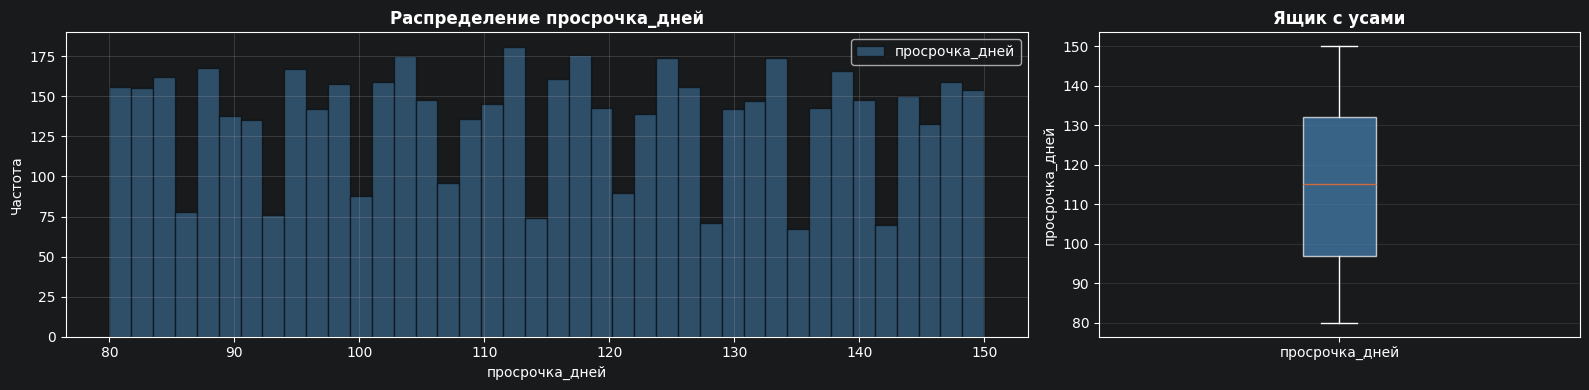

In [10]:
plot_distribution(datasets['loan_payment_credit'], density=False)

---
Датасет `ds_15_loan_payment_credit.csv` содержит 3 столбца и 5500 строк, в которых представлена информация о просрочках платежа.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `дата_начала_периода` содержит дату и хранится в типе данных `str`, тип данных следует преобразовать в `datetime64`.
- Столбец `просрочка_дней` содержит целочисленную информацию и хранится в типе данных `int64`, размерность можно оптимизировать.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.

-- В данных отсутствуют пропуски и дубликаты.

---

### ИАД transactions

In [11]:
reporter = DataFrameReporter(datasets['transactions'], 'transactions')
reporter.show_base_info()

Базовая информация по датасету transactions:
--------------------------------------------------


,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое
0,IDF55109846,2013-05-01,3267.59,1282.11,1457.96,5711.10,647.43,2374.78,4059.86,3657.35
1,IDF55109846,2013-06-01,3196.58,2443.37,1334.20,5824.65,1067.55,2187.11,4592.26,3322.61
2,IDF55109846,2013-07-01,3550.54,4277.72,1463.75,5209.51,1167.95,2076.54,3605.25,3467.06
3,IDF55109846,2013-08-01,3385.98,4530.63,1261.40,5765.96,986.99,2231.77,2209.39,3354.44
4,IDF55109846,2013-09-01,3214.84,4146.65,1405.15,5632.11,640.76,2156.67,1519.46,4352.90


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   ID          577494 non-null  str    
 1   date        577494 non-null  str    
 2   MCC_5300    577494 non-null  float64
 3   MCC_5814    577494 non-null  float64
 4   MCC_5812    577494 non-null  float64
 5   MCC_5411    577494 non-null  float64
 6   MCC_3990    577494 non-null  float64
 7   MCC_5722    577494 non-null  float64
 8   MCC_4900    577494 non-null  float64
 9   MCC_другое  577494 non-null  float64
dtypes: float64(8), str(2)
memory usage: 44.1 MB


None

In [12]:
reporter.show_report()
reporter.show_duplicates(['ID'])

Отчёт по датасету transactions:
--------------------------------------------------
Количество столбцов: 10
Количество строк: 577494
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,min,max,std,mean,median
MCC_5300,577494.0,162.91,86939.40,8835.872,6177.123,2659.590
MCC_5814,577494.0,62.18,55720.69,5710.755,3507.682,1233.110
MCC_5812,577494.0,67.06,47969.57,4541.120,2993.863,1224.530
MCC_5411,577494.0,286.11,101301.95,12299.733,9263.100,4115.385
MCC_3990,577494.0,31.90,14261.49,1557.157,1128.117,476.890
MCC_5722,577494.0,108.40,54630.19,5005.897,3604.437,1590.120
MCC_4900,577494.0,81.29,52987.53,5567.979,3682.487,1397.065
MCC_другое,577494.0,166.26,60033.55,7190.882,5414.897,2398.330


Количество пропусков: 0
Доля пропусков: 0.000


,Количество дубликатов
ID,563994


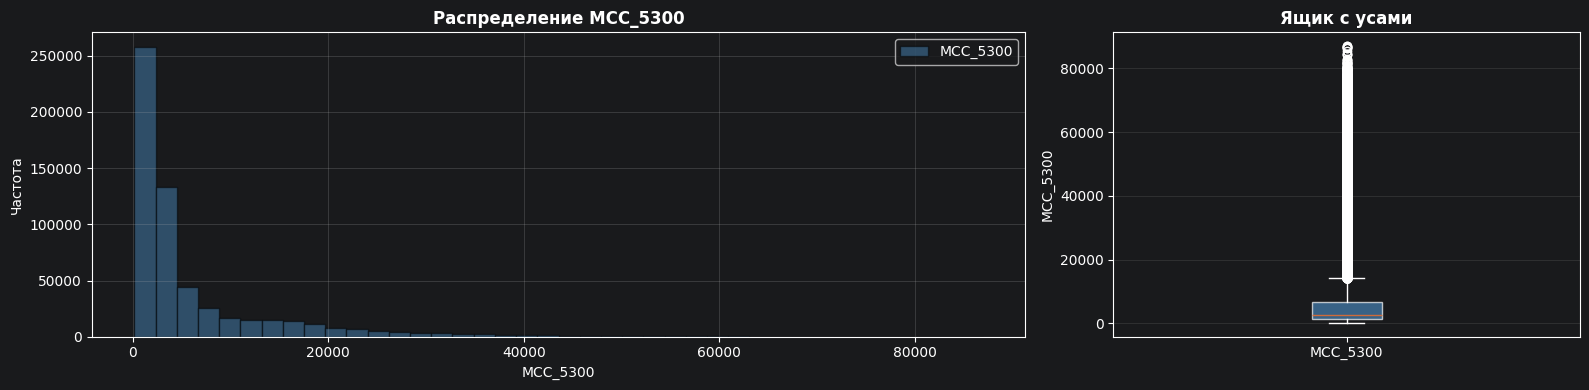

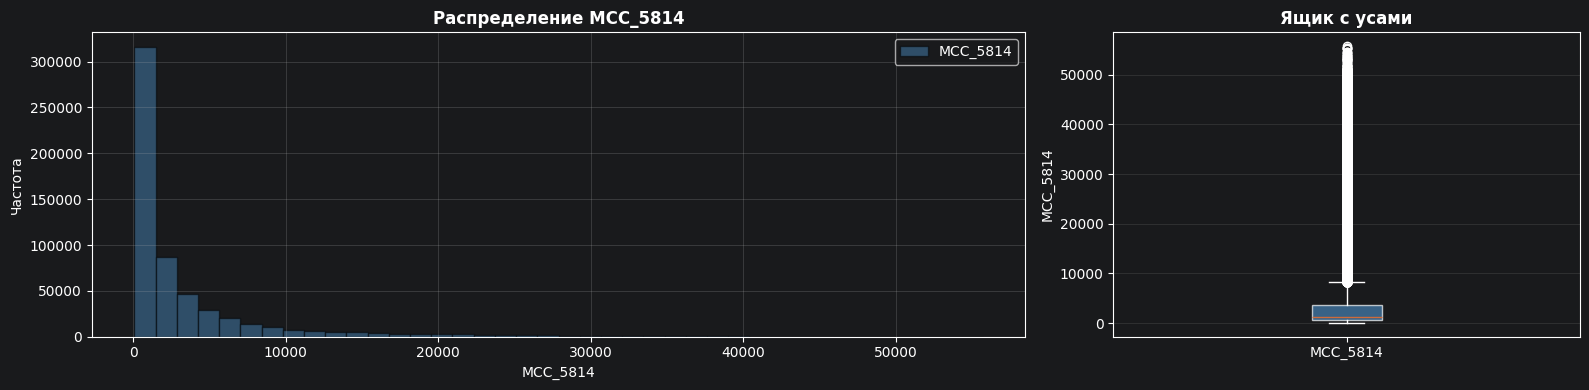

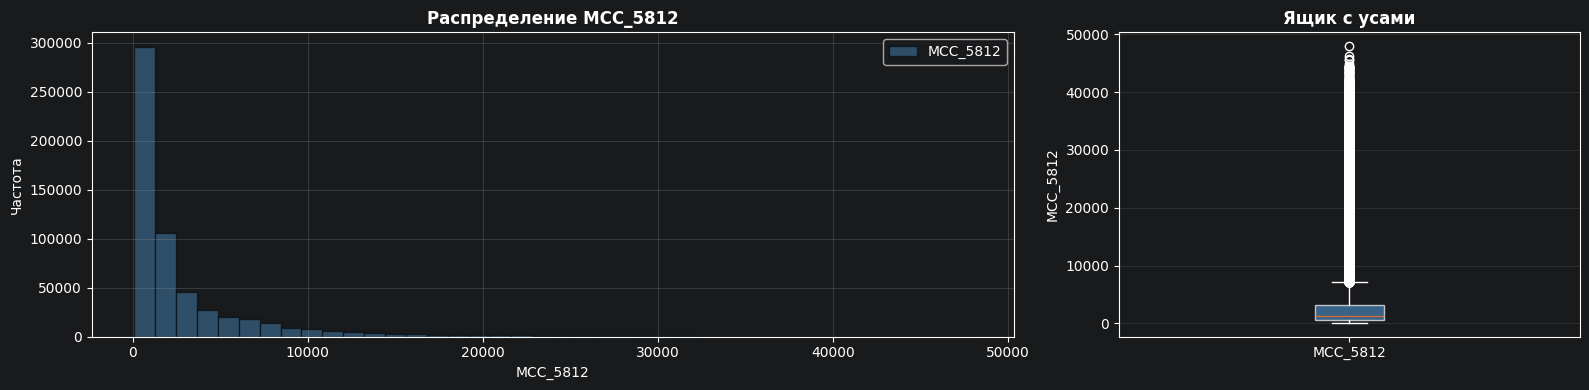

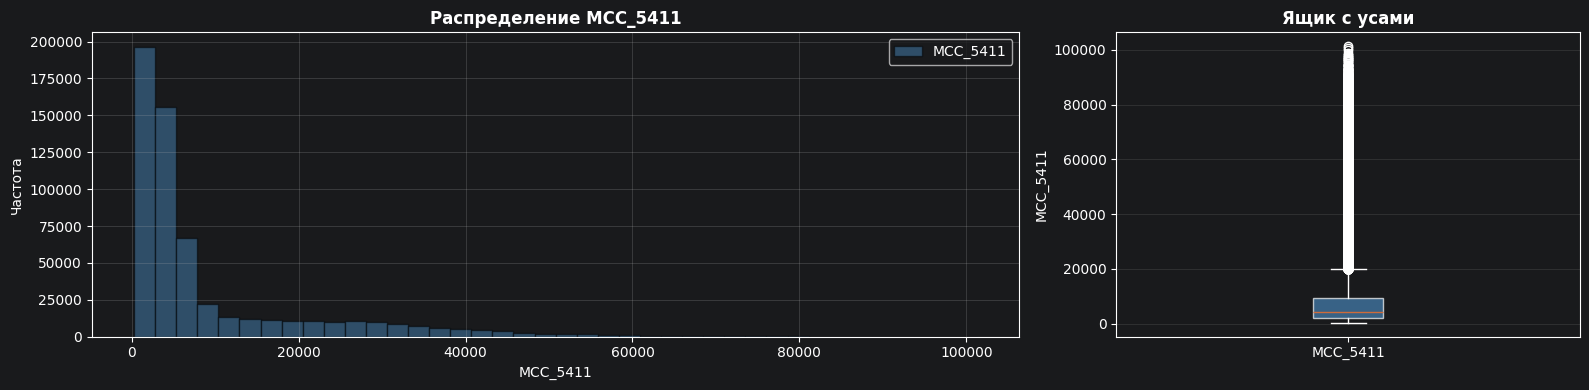

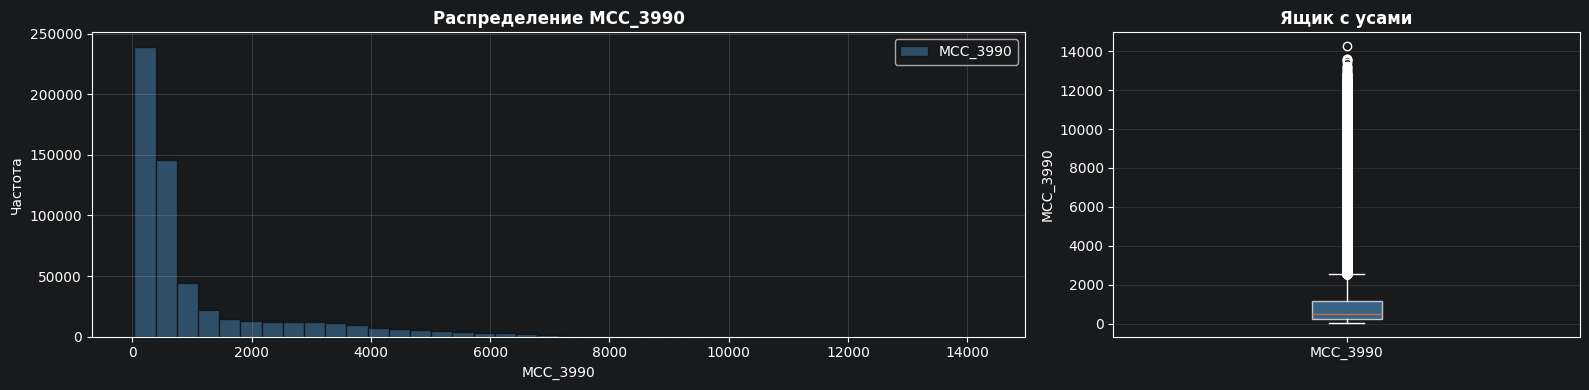

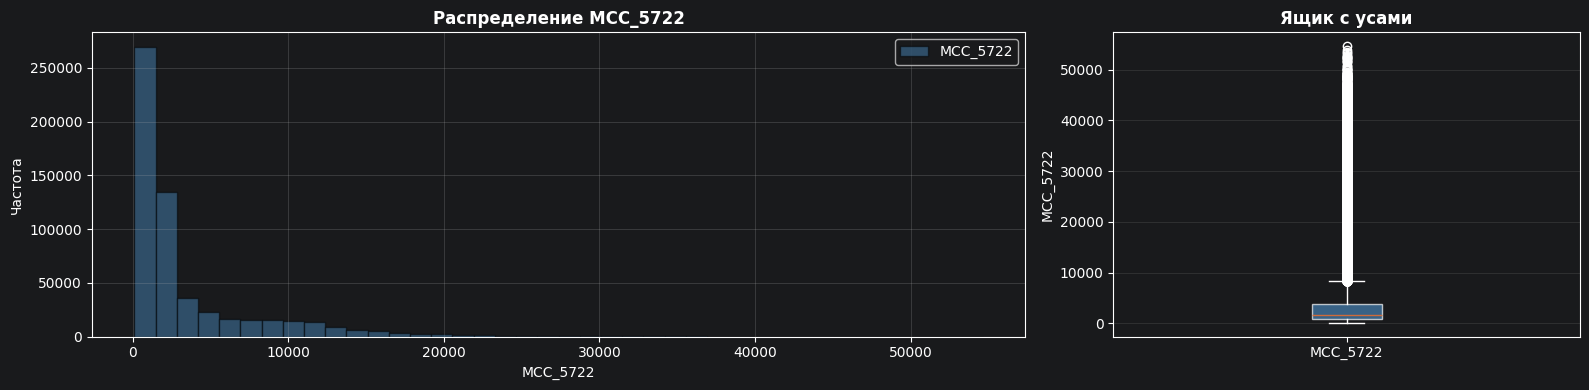

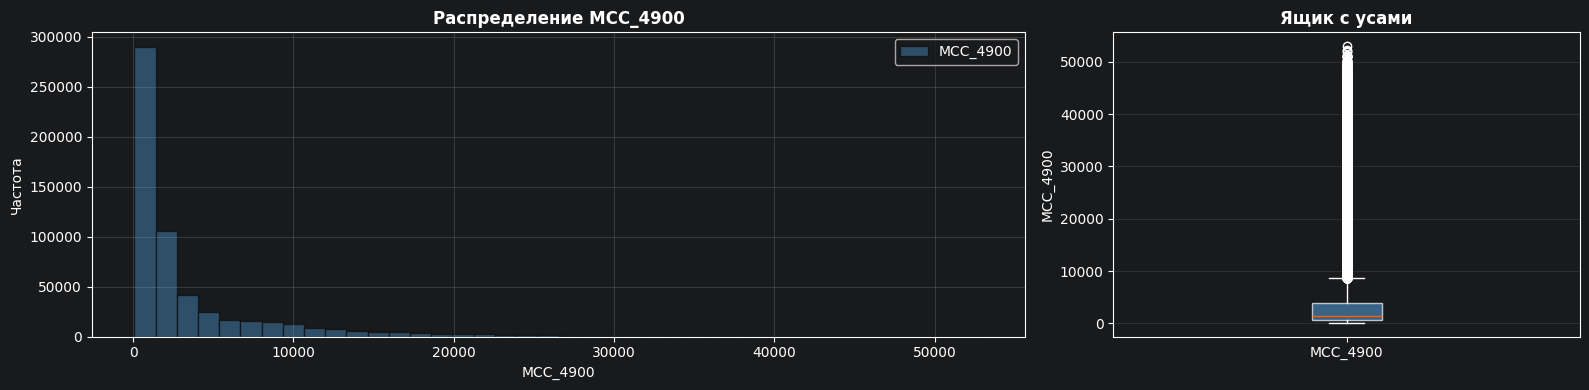

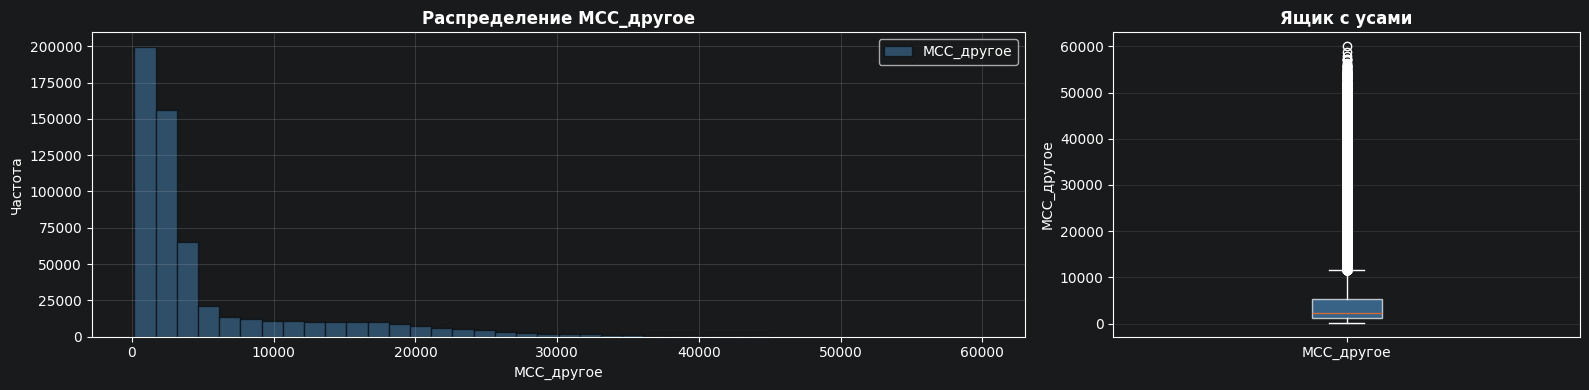

In [13]:
plot_distribution(datasets['transactions'], density=False)

---
Датасет `ds_15_transactions.csv` содержит 10 столбцов и 577494 строк, в которых представлена информация о тратах клиента по MCC-кодам.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `date` содержит дату и хранится в типе данных `str`, тип данных следует преобразовать в `datetime64`.
- Столбец `MCC_5300` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_5814` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_5812` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_5411` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_5722` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_4900` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Столбец `MCC_другое` содержит числа с плавающей точкой и хранится в типе данных `float64`, размерность можно оптимизировать.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---

### ИАД client_description

In [14]:
reporter = DataFrameReporter(
    datasets['client_description'], 'client_description'
)
reporter.show_base_info()

Базовая информация по датасету client_description:
--------------------------------------------------


,ID,возраст,семейное_положение,наличие_иждивенцев,дата_регистрации
0,IDF55109846,41,разведённые,1,2013-05-01
1,IDF54900291,45,разведённые,1,2017-12-01
2,IDF54995533,34,разведённые,1,2013-11-01
3,IDF55065581,40,нет семьи,1,2018-08-01
4,IDF55057353,66,разведённые,0,2018-05-01


<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ID                  13500 non-null  str  
 1   возраст             13500 non-null  int64
 2   семейное_положение  13500 non-null  str  
 3   наличие_иждивенцев  13500 non-null  int64
 4   дата_регистрации    13500 non-null  str  
dtypes: int64(2), str(3)
memory usage: 527.5 KB


None

In [15]:
reporter.show_report()
reporter.show_duplicates(['ID'])

Отчёт по датасету client_description:
--------------------------------------------------
Количество столбцов: 5
Количество строк: 13500
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,min,max,std,mean,median
возраст,13500.0,18.0,69.0,15.097,41.305,40.0
наличие_иждивенцев,13500.0,0.0,1.0,0.500,0.485,0.0


Количество пропусков: 0
Доля пропусков: 0.000


,Количество дубликатов
ID,0


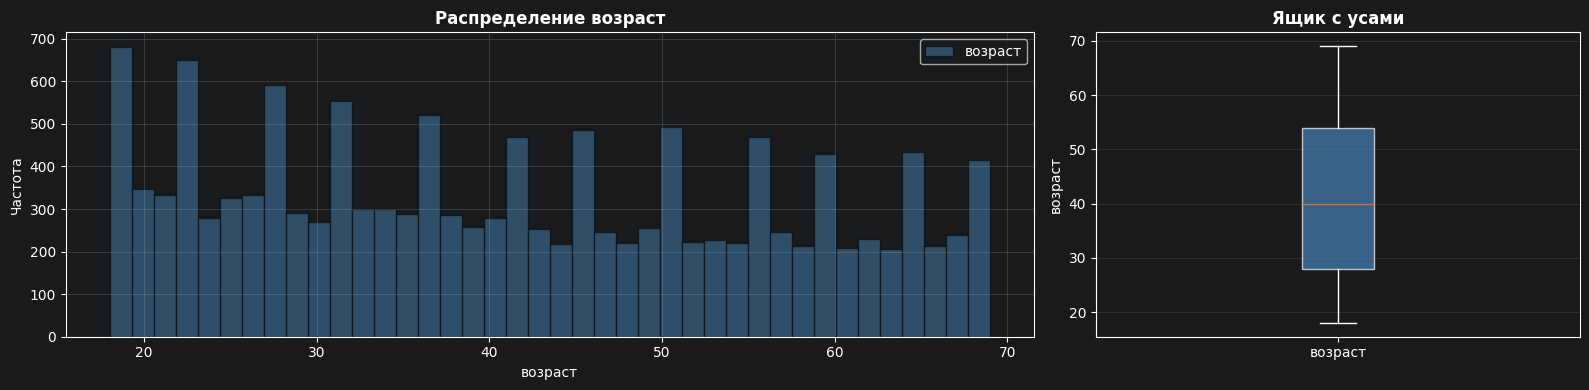

In [16]:
plot_distribution(datasets['client_description'], ['возраст'], density=False)

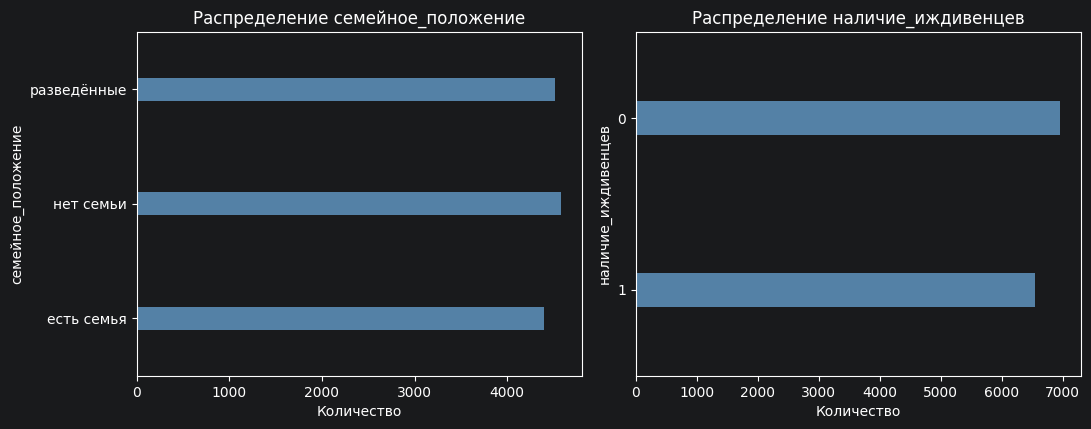

In [17]:
plot_cat_distribution(
    datasets['client_description'], ['семейное_положение','наличие_иждивенцев']
)

---
Датасет `ds_15_client_description.csv` содержит 5 столбцов и 13500 строк, в которых представлено описание клиента на момент регистрации в банке.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `возраст` содержит целочисленную информацию и хранится в типе данных `int64`, размерность можно оптимизировать.
- Столбец `семейное_положение` содержит категориальную информацию и хранится в типе данных `int64`, размерность можно оптимизировать.
- Столбец `наличие_иждивенцев` содержит бинарную информацию и хранится в типе данных `int64`, тип данных можно привести к `bool`.
- Столбец `дата_регистрации` содержит дату и хранится в типе данных `str`, тип данных следует преобразовать в `datetime`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---

### ИАД credit_description

In [18]:
reporter = DataFrameReporter(
    datasets['credit_description'], 'credit_description'
)
reporter.show_base_info()

Базовая информация по датасету credit_description:
--------------------------------------------------


,ID,доход,сумма_кредита
0,IDF55109846,27035,1960785
1,IDF54900291,64502,3375810
2,IDF54995533,90477,401700
3,IDF55065581,133475,1952655
4,IDF55057353,51324,1107870


<class 'pandas.DataFrame'>
RangeIndex: 13500 entries, 0 to 13499
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   ID             13500 non-null  str  
 1   доход          13500 non-null  int64
 2   сумма_кредита  13500 non-null  int64
dtypes: int64(2), str(1)
memory usage: 316.5 KB


None

In [19]:
reporter.show_report()
reporter.show_duplicates(['ID'])

Отчёт по датасету credit_description:
--------------------------------------------------
Количество столбцов: 3
Количество строк: 13500
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,min,max,std,mean,median
доход,13500.0,15010.0,149988.0,40045.549,79089.269,77991.5
сумма_кредита,13500.0,75000.0,3749400.0,1061381.394,1993383.459,2032732.5


Количество пропусков: 0
Доля пропусков: 0.000


,Количество дубликатов
ID,0


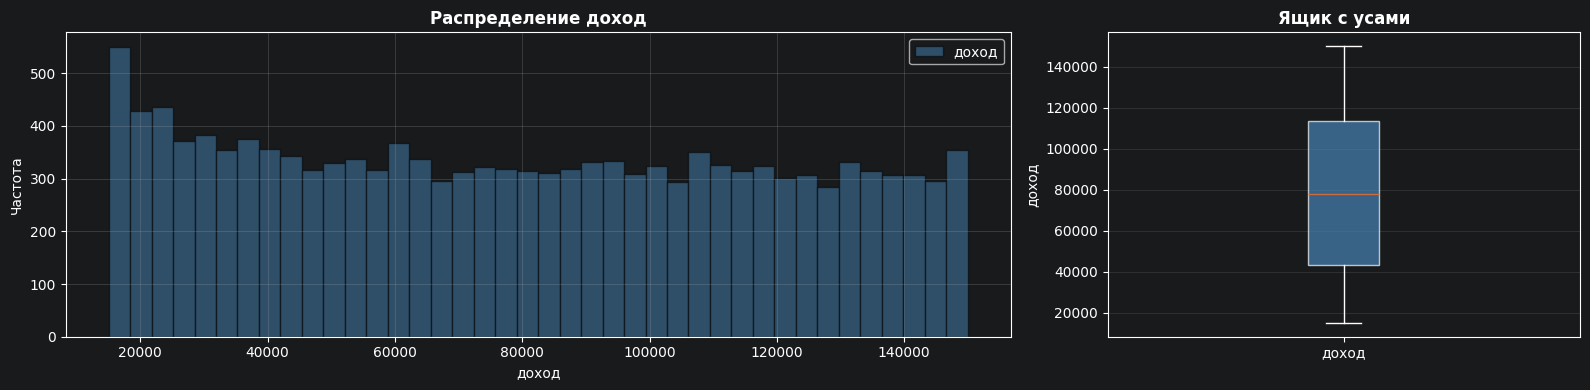

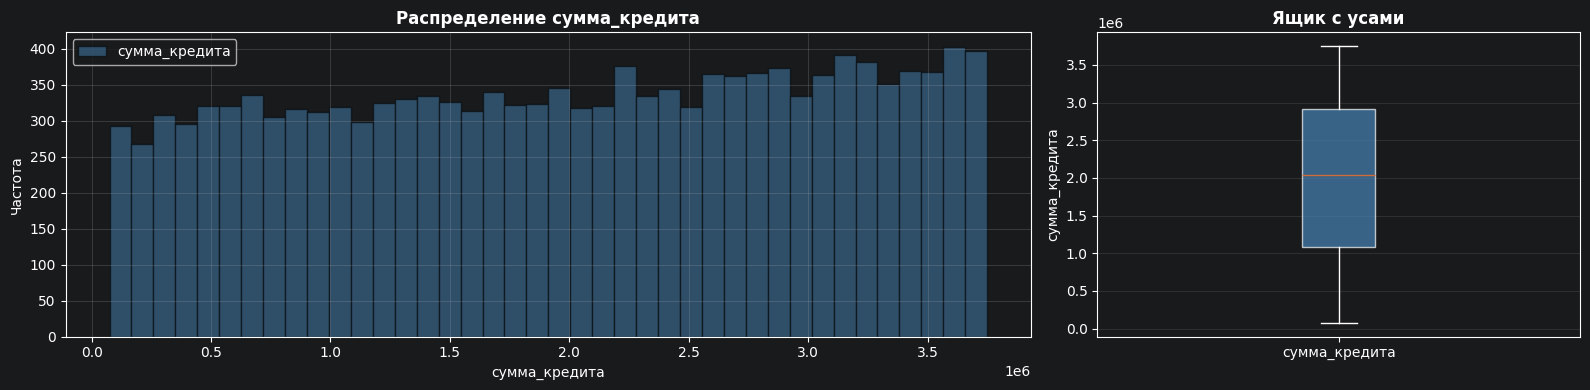

In [20]:
plot_distribution(datasets['credit_description'], density=False)

---
Датасет `ds_15_credit_description.csv` содержит 3 столбцов и 13500 строк, в которых представлено описание кредита.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `доход` содержит целочисленную информацию и хранится в типе данных `int64`, размерность можно оптимизировать.
- Столбец `сумма_кредита` содержит целочисленную информацию и хранится в типе данных `int64`, размерность можно оптимизировать.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---

### ИАД mortgage_presence

In [21]:
reporter = DataFrameReporter(
    datasets['mortgage_presence'], 'mortgage_presence'
)
reporter.show_base_info()

Базовая информация по датасету mortgage_presence:
--------------------------------------------------


,ID,дата_открытия,наличие_ипотеки
0,IDF54896351,2013-03-01,1
1,IDF54896367,2018-01-01,1
2,IDF54896414,2018-02-01,1
3,IDF54896494,2019-02-01,1
4,IDF54896615,2018-12-01,1


<class 'pandas.DataFrame'>
RangeIndex: 6609 entries, 0 to 6608
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               6609 non-null   str  
 1   дата_открытия    6609 non-null   str  
 2   наличие_ипотеки  6609 non-null   int64
dtypes: int64(1), str(2)
memory usage: 155.0 KB


None

In [22]:
reporter.show_report()
reporter.show_duplicates(['ID'])

Отчёт по датасету mortgage_presence:
--------------------------------------------------
Количество столбцов: 3
Количество строк: 6609
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,min,max,std,mean,median
наличие_ипотеки,6609.0,1.0,1.0,0.0,1.0,1.0


Количество пропусков: 0
Доля пропусков: 0.000


,Количество дубликатов
ID,0


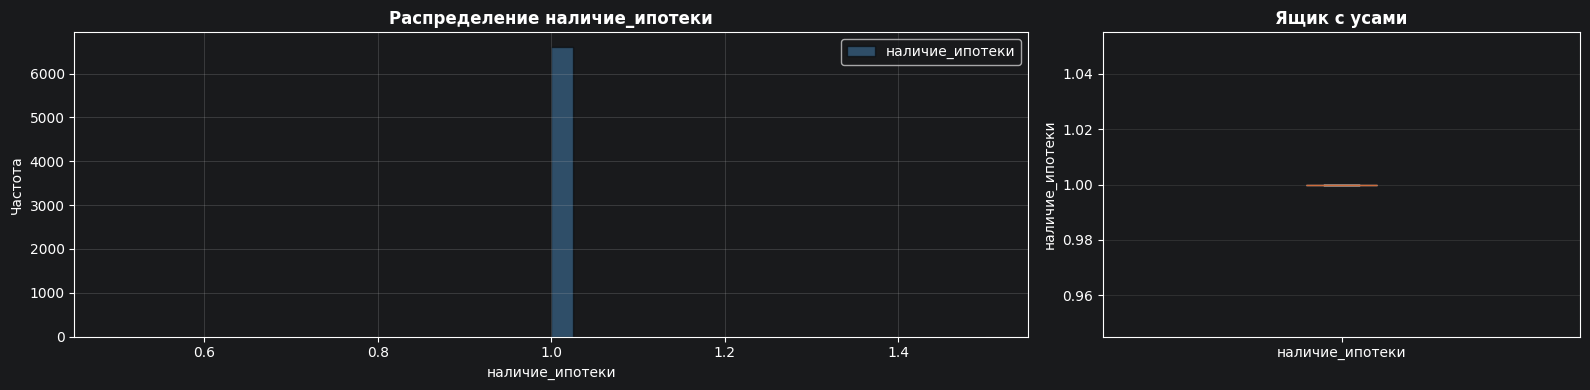

In [23]:
plot_distribution(datasets['mortgage_presence'], density=False)

---
Датасет `ds_15_mortgage_presence.csv` содержит 3 столбцов и 6609 строк, в которых представлены данные о наличии ипотеки.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `дата_открытия` содержит дату и хранится в типе данных `str`, тип данных следует привести к `datetime64`.
- Столбец `наличие_ипотеки` содержит бинарные данные и хранится в типе данных `int64`, тип данных следует привести к `bool`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---

### ИАД credit_rating

In [24]:
reporter = DataFrameReporter(
    datasets['credit_rating'], 'credit_rating'
)
reporter.show_base_info()

Базовая информация по датасету credit_rating:
--------------------------------------------------


,ID,date,кредитный_рейтинг
0,IDF55109846,2013-05-01,692
1,IDF55109846,2013-06-01,688
2,IDF55109846,2013-07-01,666
3,IDF55109846,2013-08-01,692
4,IDF55109846,2013-09-01,688


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   ID                 577494 non-null  str  
 1   date               577494 non-null  str  
 2   кредитный_рейтинг  577494 non-null  int64
dtypes: int64(1), str(2)
memory usage: 13.2 MB


None

In [25]:
reporter.show_report()
reporter.show_duplicates(['ID'])

Отчёт по датасету credit_rating:
--------------------------------------------------
Количество столбцов: 3
Количество строк: 577494
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,min,max,std,mean,median
кредитный_рейтинг,577494.0,343.0,900.0,64.359,603.191,600.0


Количество пропусков: 0
Доля пропусков: 0.000


,Количество дубликатов
ID,563994


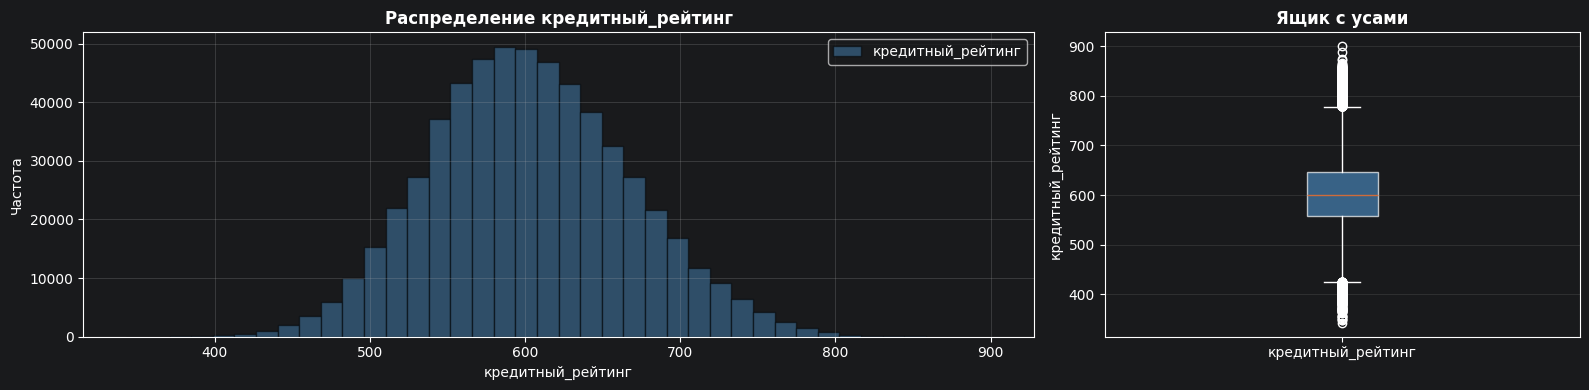

In [26]:
plot_distribution(datasets['credit_rating'], density=False)

---
Датасет `ds_15_credit_rating.csv` содержит 3 столбцов и 577494 строк, в которых представлены данные о кредитном рейтинге клиента.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `date` содержит дату и хранится в типе данных `str`, тип данных следует привести к `datetime64`.
- Столбец `кредитный_рейтинг` содержит целочисленные данные и хранится в типе данных `int64`, размерность данных можно оптимизировать.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---

### ИАД macro_data

In [27]:
reporter = DataFrameReporter(
    datasets['macro_data'], 'macro_data'
)
reporter.show_base_info()

Базовая информация по датасету macro_data:
--------------------------------------------------


,date,учетная_ставка,уровень_безработицы,инфляция
0,2013-01-01,5.5,5.7,0.97
1,2013-02-01,5.5,5.8,0.56
2,2013-03-01,5.5,5.9,0.34
3,2013-04-01,5.5,5.5,0.51
4,2013-05-01,5.5,5.4,0.66


<class 'pandas.DataFrame'>
RangeIndex: 84 entries, 0 to 83
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 84 non-null     str    
 1   учетная_ставка       84 non-null     float64
 2   уровень_безработицы  84 non-null     float64
 3   инфляция             84 non-null     float64
dtypes: float64(3), str(1)
memory usage: 2.8 KB


None

In [28]:
reporter.show_report()

Отчёт по датасету macro_data:
--------------------------------------------------
Количество столбцов: 4
Количество строк: 84
Количество дубликатов: 0
Доля дубликатов: 0.00%


,count,min,max,std,mean,median
учетная_ставка,84.0,5.50,17.00,2.466,8.639,7.750
уровень_безработицы,84.0,4.30,6.00,0.409,5.175,5.200
инфляция,84.0,-0.54,3.85,0.570,0.528,0.425


Количество пропусков: 0
Доля пропусков: 0.000


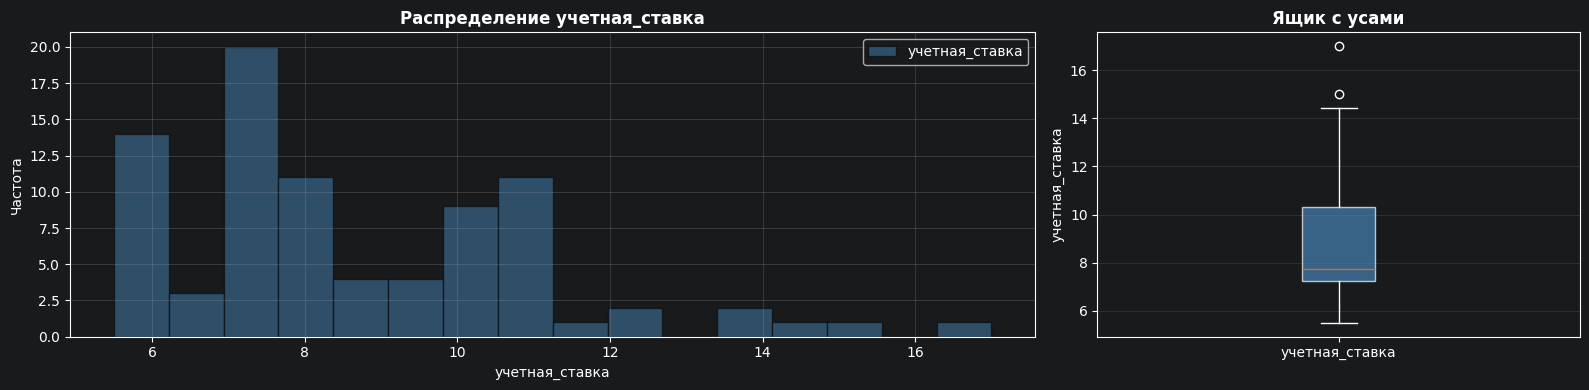

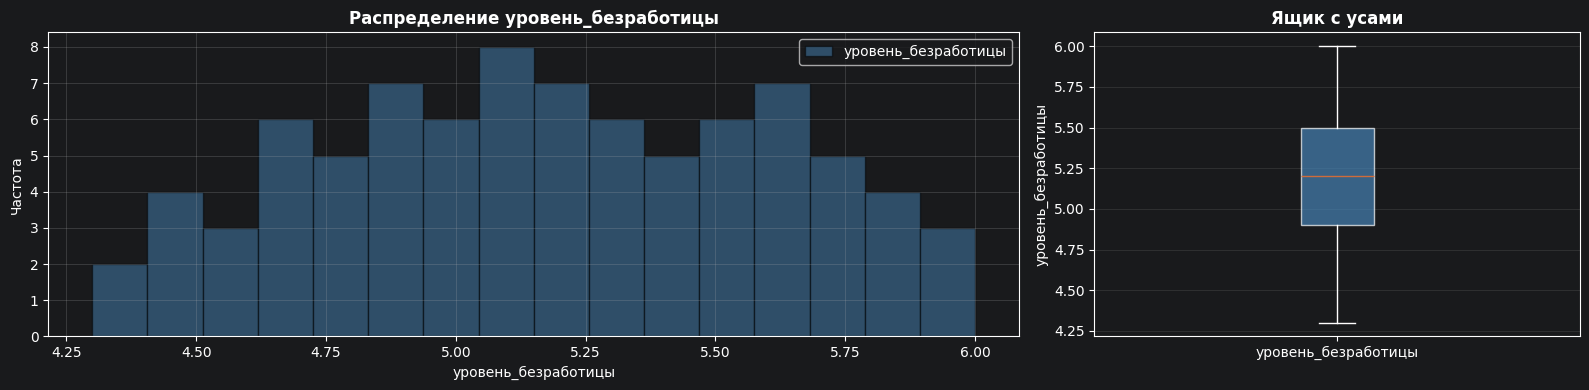

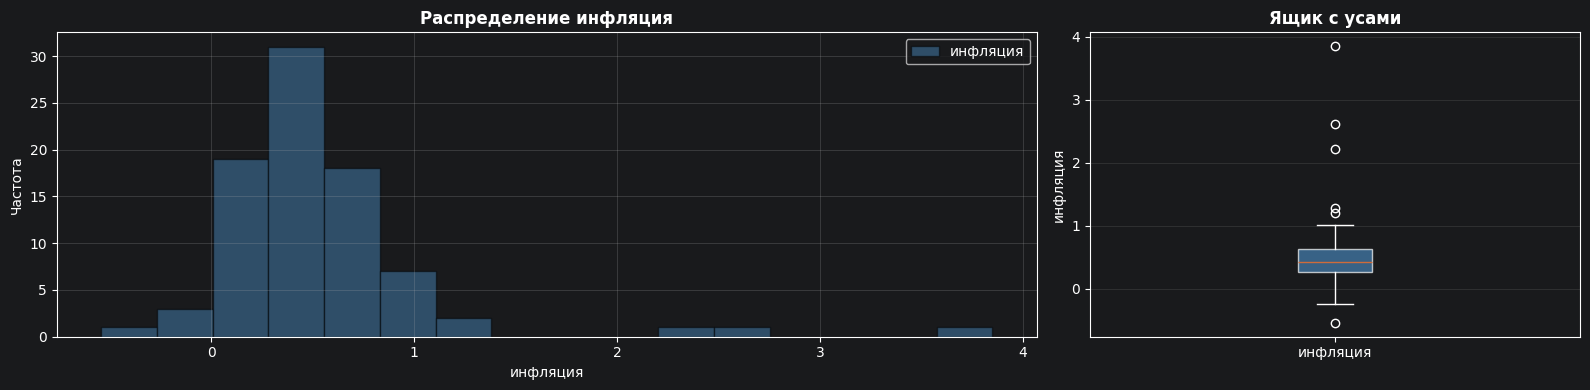

In [29]:
plot_distribution(datasets['macro_data'], bins=16, density=False)

---
Датасет `ds_15_macro_data.csv` содержит 4 столбцов и 84 строк, в которых представлены данные о макроэкономических показателях России.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбец `date` содержит дату и хранится в типе данных `str`, тип данных следует привести к `datetime64`.
- Столбец `учетная_ставка` содержит цисла с плавающей точкой и хранится в типе данных `float64`, размерность данных можно оптимизировать.
- Столбец `уровень_безработицы` содержит цисла с плавающей точкой и хранится в типе данных `float64`, размерность данных можно оптимизировать.
- Столбец `инфляция` содержит цисла с плавающей точкой и хранится в типе данных `float64`, размерность данных можно оптимизировать.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---


### ИАД cohort_grid

In [30]:
reporter = DataFrameReporter(
    datasets['cohort_grid'], 'cohort_grid'
)
reporter.show_base_info()

Базовая информация по датасету cohort_grid:
--------------------------------------------------


,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   ID          577494 non-null  str  
 1   score_date  577494 non-null  str  
dtypes: str(2)
memory usage: 8.8 MB


None

In [31]:
reporter.show_report()
reporter.show_duplicates(['ID'])

Отчёт по датасету cohort_grid:
--------------------------------------------------
Количество столбцов: 2
Количество строк: 577494
Количество дубликатов: 0
Доля дубликатов: 0.00%
Количество пропусков: 0
Доля пропусков: 0.000


,Количество дубликатов
ID,563994


---
Датасет `ds_15_cohort_grid.csv` содержит 4 столбцов и 84 строк, в которых представлены данные о дате проведения поведенческого скоринга.

После первичного анализа данных можно сделать следующие выводы:
- Названия столбцов следует привести в нижний регистр.
- Столбцы `ID` содержит информацию об идентификаторе клиента и хранится в типк данных `str`, оптимизировать этот столбец не понадобится так как он не будет участвовать в обучении модели.
- Столбец `score_date` содержит дату и хранится в типе данных `str`, тип данных следует привести к `datetime64`.
- Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
---


## Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.



### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.


In [32]:
# Класс оптимизации типов данных датафрейма
class DataFrameNormalizer:
    def __init__(self, df):
        self.df = df

    def run(self,
        to_int: list = None,
        to_float: list = None,
        to_category: list = None,
        to_date: list = None
    ) -> pd.DataFrame:
        original_df = self.df.copy()
        if to_int:
            self.to_int(to_int)
        if to_float:
            self.to_float(to_float)
        if to_category:
            self.to_category(to_category)
        if to_date:
            self.to_date(to_date)
        return pd.concat([
            original_df.dtypes.rename('До изменений'),
            self.df.dtypes.rename('После изменений')
        ], axis=1)

    def to_int(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='integer')

    def to_float(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_numeric(self.df[column], downcast='float')

    def to_category(self, columns: list) -> None:
        for column in columns:
            self.df[column] = self.df[column].astype('category')

    def to_date(self, columns: list) -> None:
        for column in columns:
            self.df[column] = pd.to_datetime(self.df[column].astype(str))

In [33]:
#Оптимизация датафрейма loan_payment_credit
DataFrameNormalizer(datasets['loan_payment_credit']).run(to_date=['дата_начала_периода'],to_int=['просрочка_дней'])

,До изменений,После изменений
ID,str,str
дата_начала_периода,str,datetime64[us]
просрочка_дней,int64,int16


In [34]:
#Оптимизация датафрейма transactions
DataFrameNormalizer(datasets['transactions']).run(
    to_date=['date'],
    to_float=['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411',
              'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое']
)

,До изменений,После изменений
ID,str,str
date,str,datetime64[us]
MCC_5300,float64,float64
MCC_5814,float64,float64
MCC_5812,float64,float64
MCC_5411,float64,float64
MCC_3990,float64,float32
MCC_5722,float64,float64
MCC_4900,float64,float64
MCC_другое,float64,float64


In [35]:
#Оптимизация датафрейма client_description
DataFrameNormalizer(datasets['client_description']).run(
    to_date=['дата_регистрации'],
    to_int=['возраст', 'наличие_иждивенцев'],
    to_category=['семейное_положение']
)

,До изменений,После изменений
ID,str,str
возраст,int64,int8
семейное_положение,str,category
наличие_иждивенцев,int64,int8
дата_регистрации,str,datetime64[us]


In [36]:
#Оптимизация датафрейма credit_description
DataFrameNormalizer(datasets['credit_description']).run(
    to_int=['доход', 'сумма_кредита'],
)

,До изменений,После изменений
ID,str,str
доход,int64,int32
сумма_кредита,int64,int32


In [37]:
#Оптимизация датафрейма mortgage_presence
DataFrameNormalizer(datasets['mortgage_presence']).run(
    to_date=['дата_открытия'],
    to_int=['наличие_ипотеки'],
)

,До изменений,После изменений
ID,str,str
дата_открытия,str,datetime64[us]
наличие_ипотеки,int64,int8


In [38]:
#Оптимизация датафрейма credit_rating
DataFrameNormalizer(datasets['credit_rating']).run(
    to_date=['date'],
    to_int=['кредитный_рейтинг'],
)

,До изменений,После изменений
ID,str,str
date,str,datetime64[us]
кредитный_рейтинг,int64,int16


In [39]:
#Оптимизация датафрейма macro_data
DataFrameNormalizer(datasets['macro_data']).run(
    to_date=['date'],
    to_float=['учетная_ставка', 'уровень_безработицы', 'инфляция'],
)

,До изменений,После изменений
date,str,datetime64[us]
учетная_ставка,float64,float32
уровень_безработицы,float64,float32
инфляция,float64,float32


In [40]:
#Оптимизация датафрейма cohort_grid
DataFrameNormalizer(datasets['cohort_grid']).run(
    to_date=['score_date']
)

,До изменений,После изменений
ID,str,str
score_date,str,datetime64[us]


In [41]:
# Объединение loan_payment_credit и transactions
# df = datasets['loan_payment_credit'].merge(
#     datasets['transactions'],
#     left_on=['ID', ''],
#     right_on=['ID', ''],
#     how='outer'
# )

In [42]:
# Объединение df и client_description
df = datasets['transactions'].merge(
    datasets['client_description'],
    left_on=['ID'],
    right_on=['ID'],
    how='outer'
)

In [43]:
# Объединение df и credit_description
df = df.merge(
    datasets['credit_description'],
    left_on=['ID'],
    right_on=['ID'],
    how='outer'
)

In [44]:
# Объединение df и mortgage_presence
df = df.merge(
    datasets['mortgage_presence'],
    left_on=['ID'],
    right_on=['ID'],
    how='outer'
)

In [45]:
# Объединение df и credit_rating
df = df.merge(
    datasets['credit_rating'],
    left_on=['ID', 'date'],
    right_on=['ID', 'date'],
    how='outer'
)

In [46]:
# Объединение df и macro_data
df = df.merge(
    datasets['macro_data'],
    left_on=['date'],
    right_on=['date'],
    how='outer'
)

In [47]:
# Объединение df и cohort_grid
df = df.merge(
    datasets['cohort_grid'],
    left_on=['ID', 'date'],
    right_on=['ID', 'score_date'],
    how='outer'
)

In [48]:
df = df.merge(
    datasets['loan_payment_credit'],
    left_on=['ID', 'date'],
    right_on=['ID', 'дата_начала_периода'],
    how='left'
)
df['просрочка_дней'] = df['просрочка_дней'].fillna(0)

df = df.sort_values(['ID', 'date'])
df['просрочка_дней_expanding_max'] = df.groupby('ID')[
    'просрочка_дней'].expanding().max().values
df = df.sort_values(['date', 'ID'])


In [49]:
df.head(5)

,ID,date,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,MCC_другое,...,дата_открытия,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,score_date,дата_начала_периода,просрочка_дней,просрочка_дней_expanding_max
1195,IDF54897139,2013-01-01,13197.14,4496.55,5001.23,21940.53,2424.159912,8892.09,14706.82,12827.45,...,2013-01-01,1.0,665,5.5,5.7,0.97,2013-01-01,NaT,0.0,0.0
2021,IDF54897415,2013-01-01,13927.97,4891.16,5307.98,25506.59,2756.600098,8666.92,18673.84,15548.56,...,2013-01-01,1.0,691,5.5,5.7,0.97,2013-01-01,NaT,0.0,0.0
4023,IDF54898248,2013-01-01,16945.25,6237.96,6863.49,32969.39,3494.459961,11387.98,20810.72,18274.06,...,2013-01-01,1.0,685,5.5,5.7,0.97,2013-01-01,NaT,0.0,0.0
4704,IDF54898589,2013-01-01,9903.14,3585.22,4054.02,18519.08,2087.520020,6711.71,12152.68,11485.95,...,NaT,NaN,691,5.5,5.7,0.97,2013-01-01,NaT,0.0,0.0
8814,IDF54900261,2013-01-01,8964.12,3127.48,3487.62,15411.36,1778.760010,5667.72,10102.94,9311.06,...,2013-01-01,1.0,681,5.5,5.7,0.97,2013-01-01,NaT,0.0,0.0


In [50]:
# Поиск первого эпизода просрочки
df_loan = datasets['loan_payment_credit'].copy()
mask = (df_loan['просрочка_дней'] >= 90)
df_loan = df_loan[mask].groupby('ID', as_index=False).agg({'дата_начала_периода': 'min'})
df_loan = df_loan.rename(columns={'дата_начала_периода': 'первый_эпизод_просрочки'})
df_loan.head(5)

,ID,первый_эпизод_просрочки
0,IDF54896351,2014-10-01
1,IDF54896494,2019-07-01
2,IDF54896677,2017-09-01
3,IDF54896685,2017-11-01
4,IDF54896744,2019-02-01


In [51]:
# Облъединение df и df_loan
df = df.merge(
    df_loan,
    left_on=['ID'],
    right_on=['ID'],
    how='outer'
)

In [52]:
DataFrameNormalizer(df).run(
    to_category=['ID'],
)

,До изменений,После изменений
ID,str,category
date,datetime64[us],datetime64[us]
MCC_5300,float64,float64
MCC_5814,float64,float64
MCC_5812,float64,float64
MCC_5411,float64,float64
MCC_3990,float32,float32
MCC_5722,float64,float64
MCC_4900,float64,float64
MCC_другое,float64,float64


In [53]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 27 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   ID                            577494 non-null  category      
 1   date                          577494 non-null  datetime64[us]
 2   MCC_5300                      577494 non-null  float64       
 3   MCC_5814                      577494 non-null  float64       
 4   MCC_5812                      577494 non-null  float64       
 5   MCC_5411                      577494 non-null  float64       
 6   MCC_3990                      577494 non-null  float32       
 7   MCC_5722                      577494 non-null  float64       
 8   MCC_4900                      577494 non-null  float64       
 9   MCC_другое                    577494 non-null  float64       
 10  возраст                       577494 non-null  int8          
 11  семейное_положение      

In [54]:
target_mask = (
    (df['просрочка_дней_expanding_max'] >= 90 ) &
    (df['score_date'].between(
        df['первый_эпизод_просрочки'],
        df['первый_эпизод_просрочки'] + pd.Timedelta(days=365))
    )
)
df['target'] = target_mask.astype(int)

In [56]:
# Проверка подсчета target
df[df['ID'] == 'IDF54896685'][['ID','дата_начала_периода', 'просрочка_дней', 'просрочка_дней_expanding_max', 'date', 'score_date','target', 'первый_эпизод_просрочки']].head(30)

,ID,дата_начала_периода,просрочка_дней,просрочка_дней_expanding_max,date,score_date,target,первый_эпизод_просрочки
576,IDF54896685,NaT,0.0,0.0,2017-01-01,2017-01-01,0,2017-11-01
577,IDF54896685,NaT,0.0,0.0,2017-02-01,2017-02-01,0,2017-11-01
578,IDF54896685,NaT,0.0,0.0,2017-03-01,2017-03-01,0,2017-11-01
579,IDF54896685,NaT,0.0,0.0,2017-04-01,2017-04-01,0,2017-11-01
580,IDF54896685,NaT,0.0,0.0,2017-05-01,2017-05-01,0,2017-11-01
581,IDF54896685,NaT,0.0,0.0,2017-06-01,2017-06-01,0,2017-11-01
582,IDF54896685,NaT,0.0,0.0,2017-07-01,2017-07-01,0,2017-11-01
583,IDF54896685,NaT,0.0,0.0,2017-08-01,2017-08-01,0,2017-11-01
584,IDF54896685,NaT,0.0,0.0,2017-09-01,2017-09-01,0,2017-11-01
585,IDF54896685,NaT,0.0,0.0,2017-10-01,2017-10-01,0,2017-11-01


In [57]:
dft = df[
    (df['первый_эпизод_просрочки'].isna()) |
    (df['первый_эпизод_просрочки'] >= df['score_date'])
]
dft.shape

(438379, 28)


### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.

In [61]:
# количество дубликатов
dft.duplicated().sum()

np.int64(0)

---
Итоговая таблица содержит 27 столбцов и 72615 строк.

После первичного анализа данных можно сделать следующие выводы:
- Данные в столбцах оптимизированы и преведены к целевому виду, за исключением столбца `target`, его размерность можно оптимизировать.
- `дата_открытия` - есть пропуски, пропуски заполним индикаторным значением 01.01.2100
- `наличие_ипотеки` - есть пропуски, их заменим на 0, так как отсутствие данных значит отсутствие ипотеки, судя по первичному датасету.
- `первый_эпизод_просрочки` - технический столбец, нужен был для опеределения даты первого эпизода просрочки, его целиком удалим.
---


## Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

In [62]:
# Сортировка датасета по дате
dft = dft.sort_values(by=['date', 'ID']).reset_index(drop=True)
dft = dft.drop(columns=['первый_эпизод_просрочки'])

In [63]:
dft.info()

<class 'pandas.DataFrame'>
RangeIndex: 438379 entries, 0 to 438378
Data columns (total 27 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   ID                            438379 non-null  category      
 1   date                          438379 non-null  datetime64[us]
 2   MCC_5300                      438379 non-null  float64       
 3   MCC_5814                      438379 non-null  float64       
 4   MCC_5812                      438379 non-null  float64       
 5   MCC_5411                      438379 non-null  float64       
 6   MCC_3990                      438379 non-null  float32       
 7   MCC_5722                      438379 non-null  float64       
 8   MCC_4900                      438379 non-null  float64       
 9   MCC_другое                    438379 non-null  float64       
 10  возраст                       438379 non-null  int8          
 11  семейное_положение      

Признаки которые будем добавлять:
- sin/cos текущего месяца
- sin/cos месяца `дата_регистрации`
- сумма всех MCC за прошлый месяц
- средняя сумма всех MCC за прошлый квартал
- кумулятивное среднее всех MCC
- количество месяцев с даты регистрации в банке
- количество месяцев с даты открытия ипотеки
- доход - сумма всех MCC за прошлый месяц
- скользящее среднее из (доход - сумма всех MCC на текущий месяц) за 3 предидущих месяца
- доход / наличие_иждивенцев + семейное_положение(холост - 1, разведен - 1, женат = 2)
- скользящее среднее на доход / наличие_иждивенцев + семейное_положение(холост - 1, разведен - 1, женат = 2) за 3 предидущих месяца


In [133]:
def create_features(X):
    x_copy = X.copy()
    x_copy = x_copy.sort_values(['ID', 'date'])

    cyclic_cols = ['date', 'дата_регистрации']
    for col in cyclic_cols:
        month_num = x_copy[col].dt.month
        x_copy[f'{col}_month_num_cos'] = np.cos(2 * np.pi * month_num / 12)
        x_copy[f'{col}_month_num_sin'] = np.sin(2 * np.pi * month_num / 12)

    drop_na_rows = []
    macro_cols = ['учетная_ставка', 'уровень_безработицы', 'инфляция']
    for col in macro_cols:
        lag_series = x_copy.groupby('date')[col].first().shift(1)
        x_copy[f'{col}_lag_1'] = x_copy['date'].map(lag_series)
        rolling_series = lag_series.rolling(3, min_periods=1).mean()
        x_copy[f'{col}_rolling_mean_3'] = x_copy['date'].map(rolling_series)
        drop_na_rows.append(f'{col}_lag_1')
        drop_na_rows.append(f'{col}_rolling_mean_3')

    mcc_cols = ['MCC_5300', 'MCC_5814', 'MCC_5812', 'MCC_5411',
              'MCC_3990', 'MCC_5722', 'MCC_4900', 'MCC_другое']
    for col in mcc_cols:
        x_copy[f'{col}_lag_1'] = x_copy.groupby('ID')[col].shift(1)
        drop_na_rows.append(f'{col}_lag_1')

    x_copy['MCC_sum'] = x_copy[mcc_cols].sum(axis=1)
    x_copy['MCC_sum_lag_1'] = x_copy.groupby('ID')['MCC_sum'].shift(1)

    x_copy['MCC_sum_rolling_mean_3'] = x_copy.groupby('ID')[
        'MCC_sum_lag_1'].rolling(3, min_periods=1).mean().values
    x_copy['MCC_sum_expanding_mean'] = x_copy.groupby('ID')[
        'MCC_sum_lag_1'].expanding().mean().values

    drop_na_rows.append('MCC_sum_rolling_mean_3')
    drop_na_rows.append('MCC_sum_expanding_mean')

    x_copy['months_from_registration'] = round((
            x_copy['date'] - x_copy['дата_регистрации']
    ).dt.days / 30, 2)
    open_mask = x_copy['дата_открытия'].notna()
    x_copy['months_from_mortgage'] = np.where(
        open_mask,
        round((x_copy['date'] - x_copy['дата_открытия']).dt.days / 30, 2), -999
    )

    status_mapping = {
        'есть семья': 2,
        'нет семьи': 1,
        'разведённые': 1
    }
    x_copy['коэф_семейное_положение'] = x_copy['семейное_положение'].map(
        status_mapping
    )
    x_copy['доход_lag_1'] = x_copy.groupby('ID')['доход'].shift(1)
    x_copy['доход_на_члена_семьи_lag_1'] = x_copy['доход_lag_1'] / (
        x_copy['наличие_иждивенцев'] + x_copy['коэф_семейное_положение']
    )
    x_copy['доход_на_члена_семьи_rolling_mean_3'] = x_copy.groupby(
        'ID')['доход_на_члена_семьи_lag_1'].rolling(
        3, min_periods=1).mean().values
    x_copy['доход_на_члена_семьи_expanding_mean'] = x_copy.groupby('ID')[
        'доход_на_члена_семьи_lag_1'].expanding().mean().values
    drop_na_rows.append('доход_lag_1')
    drop_na_rows.append('доход_на_члена_семьи_lag_1')
    drop_na_rows.append('доход_на_члена_семьи_rolling_mean_3')
    drop_na_rows.append('доход_на_члена_семьи_expanding_mean')

    x_copy['balance_lag_1'] = x_copy['доход_lag_1'] - x_copy['MCC_sum_lag_1']
    x_copy['balance_rolling_mean_3'] = x_copy.groupby(
        'ID')['balance_lag_1'].rolling(3, min_periods=1).mean().values
    x_copy['balance_expanding_mean'] = x_copy.groupby('ID')[
        'balance_lag_1'].expanding().mean().values
    drop_na_rows.append('balance_lag_1')
    drop_na_rows.append('balance_rolling_mean_3')
    drop_na_rows.append('balance_expanding_mean')

    x_copy['просрочка_дней_lag_1'] = x_copy.groupby('ID')['просрочка_дней'].shift(1)
    drop_na_rows.append('просрочка_дней_lag_1')

    x_copy = x_copy.dropna(
        subset=drop_na_rows
    )
    x_copy = x_copy.sort_values(['date', 'ID'])

    return x_copy

In [134]:
df_enh = create_features(dft)

In [135]:
df_enh[df_enh['ID'] == 'IDF54898248'].T

,154,441,898,1535,2335,3303,4438,5733,7186,8793,10557,12465,14529,16747,19133
ID,IDF54898248,IDF54898248,IDF54898248,IDF54898248,IDF54898248,IDF54898248,IDF54898248,IDF54898248,IDF54898248,IDF54898248,IDF54898248,IDF54898248,IDF54898248,IDF54898248,IDF54898248
date,2013-02-01 00:00:00,2013-03-01 00:00:00,2013-04-01 00:00:00,2013-05-01 00:00:00,2013-06-01 00:00:00,2013-07-01 00:00:00,2013-08-01 00:00:00,2013-09-01 00:00:00,2013-10-01 00:00:00,2013-11-01 00:00:00,2013-12-01 00:00:00,2014-01-01 00:00:00,2014-02-01 00:00:00,2014-03-01 00:00:00,2014-04-01 00:00:00
MCC_5300,18418.27,17729.75,20675.48,20635.68,21088.17,24045.26,41980.19,45352.62,53803.72,29472.13,27696.26,25841.34,34568.37,36392.75,5091.5
MCC_5814,15298.92,22816.57,26693.08,30717.65,17188.87,7860.59,7738.66,6774.83,10041.45,8674.24,10468.27,9361.21,25577.87,43597.62,7060.35
MCC_5812,7184.03,6979.78,7992.97,8940.72,16446.71,20935.48,23271.6,20748.08,18047.1,9817.78,11402.03,10797.59,15046.23,14704.52,1965.87
MCC_5411,31522.36,31886.85,37278.95,35468.55,52926.57,51996.26,44339.98,34552.88,49543.18,46024.36,43806.07,50818.6,62991.68,57713.3,7920.98
MCC_3990,5576.779785,6069.290039,6383.120117,4322.430176,3972.090088,3907.26001,4040.030029,3847.01001,4987.430176,5186.899902,4957.870117,4973.819824,10952.230469,12053.169922,1546.459961
MCC_5722,10995.42,12389.25,12753.98,14183.99,13820.89,11680.08,13109.61,13203.89,21732.97,28660.86,37437.0,16890.51,24007.62,23436.33,3194.91
MCC_4900,24395.99,22968.82,15869.66,10848.43,10602.14,11007.44,10040.36,10286.84,13587.69,12890.09,12563.86,27490.9,50909.87,43030.19,3698.12
MCC_другое,19800.74,19017.29,19211.24,25990.39,32081.36,25753.56,20143.69,20663.84,28220.28,26180.96,26134.99,27227.57,38904.57,38574.19,4762.03


## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

In [136]:
df_enh.info()

<class 'pandas.DataFrame'>
Index: 424879 entries, 152 to 438378
Data columns (total 60 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   ID                                   424879 non-null  category      
 1   date                                 424879 non-null  datetime64[us]
 2   MCC_5300                             424879 non-null  float64       
 3   MCC_5814                             424879 non-null  float64       
 4   MCC_5812                             424879 non-null  float64       
 5   MCC_5411                             424879 non-null  float64       
 6   MCC_3990                             424879 non-null  float32       
 7   MCC_5722                             424879 non-null  float64       
 8   MCC_4900                             424879 non-null  float64       
 9   MCC_другое                           424879 non-null  float64       
 10  возраст   

In [137]:
df_enh.head(5).T

,152,153,154,155,158
ID,IDF54897139,IDF54897415,IDF54898248,IDF54898589,IDF54900261
date,2013-02-01 00:00:00,2013-02-01 00:00:00,2013-02-01 00:00:00,2013-02-01 00:00:00,2013-02-01 00:00:00
MCC_5300,11331.47,13547.0,18418.27,10736.83,10123.09
MCC_5814,9602.02,11324.65,15298.92,8376.05,7315.11
MCC_5812,4180.57,6019.38,7184.03,4114.84,3889.47
MCC_5411,19799.56,25727.51,31522.36,17980.4,16671.94
MCC_3990,3665.570068,4084.850098,5576.779785,2999.570068,3161.290039
MCC_5722,7712.41,8962.92,10995.42,6066.95,6168.38
MCC_4900,15939.53,20110.55,24395.99,16081.13,14789.92
MCC_другое,11646.34,14078.64,19800.74,10020.08,9777.8


---
В финальном датафрейме 58 колонок и 67115 строк.
Пропуски данных естьв столбцах `дата_открытия` и `наличие_ипотеки`.
Пропуски в `наличие_ипотеки` заполним нулями, так как в изначальной таблице хранятся только пользователи с ипотекой, пользователей без ипотеки в той таблице не было.
Пропуски в `дата_открытия` обрабатывать не будем, так как этот столбец не будет участвовать в обучении модели.

---

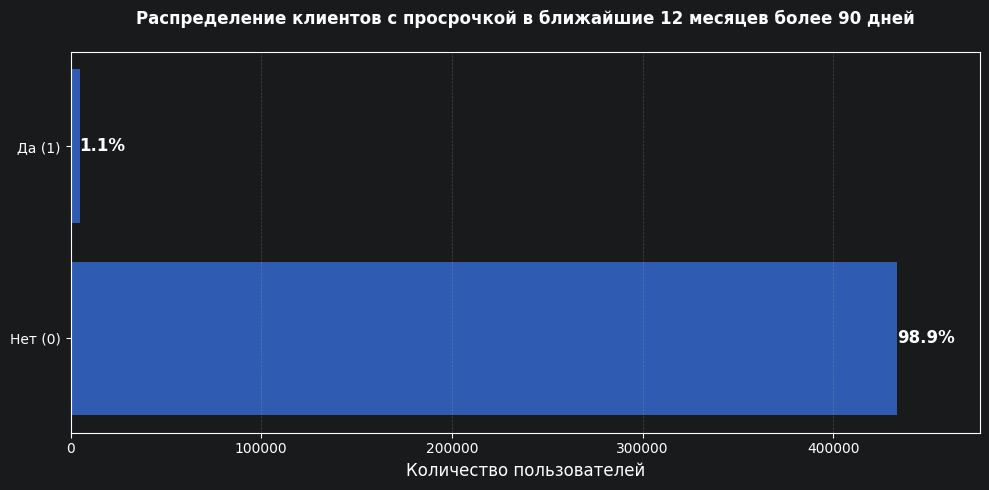

In [138]:
# Распределение пользователей с просрочкой
def plot_target_class_balance(X, target_col, title):
    plt.figure(figsize=(10, 5))

    counts = X[target_col].value_counts()
    bars = plt.barh(['Нет (0)', 'Да (1)'], counts.values, alpha=0.8)

    for bar, count in zip(bars, counts.values):
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height()/2.,
            f'{count/len(X)*100:.1f}%',
            ha='left', va='center', fontsize=12, fontweight='bold'
        )

    plt.title(title, fontsize=12, fontweight='bold', pad=20)
    plt.xlabel('Количество пользователей', fontsize=12)
    plt.grid(axis='x', alpha=0.3, linestyle='--')
    plt.xlim(0, max(counts.values) * 1.1)
    plt.tight_layout()
    plt.show()

plot_target_class_balance(
    dft, 'target',
    'Распределение клиентов с просрочкой в ближайшие 12 месяцев более 90 дней'
)

In [139]:
dft['target'].value_counts()

target
0    433667
1      4712
Name: count, dtype: int64

На графике распределения видим дисбаланс классов более чем в два раза для целевой переменной. Для борьбы с дисбалансом можно использовать методы оверсемплинг или модификацию лосса.

## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

#### Подготовьте обучающую, калибровочную и тестовую выборки.
Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.

In [140]:
dft['date'].unique()

<DatetimeArray>
['2013-01-01 00:00:00', '2013-02-01 00:00:00', '2013-03-01 00:00:00',
 '2013-04-01 00:00:00', '2013-05-01 00:00:00', '2013-06-01 00:00:00',
 '2013-07-01 00:00:00', '2013-08-01 00:00:00', '2013-09-01 00:00:00',
 '2013-10-01 00:00:00', '2013-11-01 00:00:00', '2013-12-01 00:00:00',
 '2014-01-01 00:00:00', '2014-02-01 00:00:00', '2014-03-01 00:00:00',
 '2014-04-01 00:00:00', '2014-05-01 00:00:00', '2014-06-01 00:00:00',
 '2014-07-01 00:00:00', '2014-08-01 00:00:00', '2014-09-01 00:00:00',
 '2014-10-01 00:00:00', '2014-11-01 00:00:00', '2014-12-01 00:00:00',
 '2015-01-01 00:00:00', '2015-02-01 00:00:00', '2015-03-01 00:00:00',
 '2015-04-01 00:00:00', '2015-05-01 00:00:00', '2015-06-01 00:00:00',
 '2015-07-01 00:00:00', '2015-08-01 00:00:00', '2015-09-01 00:00:00',
 '2015-10-01 00:00:00', '2015-11-01 00:00:00', '2015-12-01 00:00:00',
 '2016-01-01 00:00:00', '2016-02-01 00:00:00', '2016-03-01 00:00:00',
 '2016-04-01 00:00:00', '2016-05-01 00:00:00', '2016-06-01 00:00:00',
 '20

In [141]:
# Выделяем последний год для OOT
oot_start_date = '2019-01-01'

# Данные для финального OOT-теста
df_test_oot = dft[dft['date'] >= oot_start_date]

# Данные для обучения и валидации (train_val)
df_train_val = dft[dft['date'] < oot_start_date]

X_train_val = df_train_val.drop(columns='target')
y_train_val = df_train_val['target']

X_test_oot = df_test_oot.drop(columns='target')
y_test_oot = df_test_oot['target']

print(f"Размер обучения и валидации: {len(X_train_val)} точек (до {df_train_val.index[-1]})")
print(f"Размер OOT Test: {len(X_test_oot)} точек (с {df_test_oot.index[0]} по {df_test_oot.index[-1]})")


Размер обучения и валидации: 334696 точек (до 334695)
Размер OOT Test: 103683 точек (с 334696 по 438378)


#### Обучение базовых модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

In [142]:
#Создадим пайплайн для числовых признаков
num_features = [
    'возраст',
    'сумма_кредита',
    'кредитный_рейтинг',
    'учетная_ставка',
    # 'уровень_безработицы',
    # 'инфляция',
    'date_month_num_cos',
    'date_month_num_sin',
    'дата_регистрации_month_num_cos',
    'дата_регистрации_month_num_sin',
    'MCC_5300_lag_1',
    'MCC_5814_lag_1',
    'MCC_5812_lag_1',
    'MCC_5411_lag_1',
    'MCC_3990_lag_1',
    'MCC_5722_lag_1',
    'MCC_4900_lag_1',
    'MCC_другое_lag_1',
    'MCC_sum_lag_1',
    'MCC_sum_expanding_mean',
    'учетная_ставка_lag_1',
    'уровень_безработицы_lag_1',
    'инфляция_lag_1',
    'учетная_ставка_rolling_mean_3',
    'уровень_безработицы_rolling_mean_3',
    'инфляция_rolling_mean_3',
    'months_from_registration',
    'months_from_mortgage',
    'доход_lag_1',
    'доход_на_члена_семьи_lag_1',
    'доход_на_члена_семьи_rolling_mean_3',
    'доход_на_члена_семьи_expanding_mean',
    'balance_lag_1',
    'balance_rolling_mean_3',
    'balance_expanding_mean',
    'наличие_иждивенцев',
    'наличие_ипотеки',
    # 'просрочка_дней_lag_1',
]

num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler()),
])

In [143]:
#Создадим пайплайн для категориальных признаков
cat_features = [
    'семейное_положение',
]

cat_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(
        drop='first',
        sparse_output=False,
        handle_unknown='ignore'
    ))
])

In [144]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features),
    ],
    remainder='drop',
)

In [159]:
# CV
cv_results = pd.DataFrame()
def custom_cv(pipeline, X_tmp, y_tmp, extra_name='', silent=False):
    DATE_COL = 'date'
    TARGET_COL = 'target'
    TEST_SIZE_GROUPS = 12
    gts = GroupTimeSeriesSplit(n_splits=N_FOLDS, test_size=TEST_SIZE_GROUPS)
    cv_metrics = {
        'ROC-AUC': [], 'PR-AUC': [], 'approval rate': [], 'default rate': [],
        'missed defaults rate': [], 'Fold_ID': [], 'Test_Month': []
    }
    cv_indices = []
    feature_cols = None
    for i, (train_idx, val_idx) in enumerate(
            gts.split(X_tmp, y_tmp, groups=df_train_val[DATE_COL])):

        cv_indices.append((train_idx, val_idx))

        # --- Разделяем на обучение и валидацию ---
        df_train_fold_base = df_train_val.iloc[train_idx].copy()
        df_val_fold_base = df_train_val.iloc[val_idx].copy()

        df_train_fold_engineered = create_features(df_train_fold_base)
        df_val_fold_engineered = create_features(df_val_fold_base)

        if i == 0:
            feature_cols = [
                col for col in df_train_fold_engineered.columns
                if col not in  [TARGET_COL, 'ID']
            ]

        X_train_fold = df_train_fold_engineered[feature_cols]
        y_train_fold = df_train_fold_engineered[TARGET_COL]

        X_val_fold = df_val_fold_engineered[feature_cols]
        y_val_fold = df_val_fold_engineered[TARGET_COL]

        pipeline.fit(X_train_fold, y_train_fold)
        y_pred = pipeline.predict(X_val_fold)
        y_proba = pipeline.predict_proba(X_val_fold)[:, 1]
        tn, fp, fn, tp = confusion_matrix(y_val_fold, y_pred).ravel()
        n = len(y_val_fold)

        roc_auc = roc_auc_score(y_val_fold, y_proba)
        pr_auc = average_precision_score(y_val_fold, y_proba)
        approval_rate = (fn + tn) / n
        default_rate = fn / (fn + tn)
        missed_defaults_rate = fn / (fn + tp)

        cv_metrics['ROC-AUC'].append(roc_auc)
        cv_metrics['PR-AUC'].append(pr_auc)
        cv_metrics['approval rate'].append(approval_rate)
        cv_metrics['default rate'].append(default_rate)
        cv_metrics['missed defaults rate'].append(missed_defaults_rate)
        cv_metrics['Fold_ID'].append(f'Fold {i+1}')
        cv_metrics['Test_Month'].append(
            df_val_fold_base[DATE_COL].iloc[0].strftime('%Y-%m'))
        if not silent:
            print(f"Фолд {i+1} (Тест: {cv_metrics['Test_Month'][-1]} - "
                  f"{df_val_fold_base[DATE_COL].iloc[-1].strftime('%Y-%m')}):")
            print(f" ROC-AUC: {roc_auc:.2f} | PR-AUC: {pr_auc:.2f} "
                  f"| approval rate: {approval_rate:.2f} "
                  f"| default rate: {default_rate:.3f} "
                  f"| missed default rate: {missed_defaults_rate:.3f}"
                  )

    # --- Сводка ---

    cv_results_df = pd.DataFrame(cv_metrics)
    sampler_name = None
    if 'sampler' in pipeline.named_steps:
        sampler_name = type(pipeline.named_steps['sampler']).__name__
    current_results = pd.DataFrame({
        'ROC-AUC': [round(cv_results_df['ROC-AUC'].mean(), 3)],
        'PR-AUC': [round(cv_results_df['PR-AUC'].mean(), 3)],
        'approval rate': [round(cv_results_df['approval rate'].mean(), 3)],
        'default rate': [round(cv_results_df['default rate'].mean(), 3)],
        'missed defaults rate': [
            round(cv_results_df['missed defaults rate'].mean(), 3)],
        'model': [
            type(pipeline.named_steps['model']
                 ).__name__ + ' ' + extra_name.strip()
                  ],
        'sampler': [sampler_name],
    })
    global cv_results
    cv_results = pd.concat(
        [cv_results, current_results], axis=0, ignore_index=True)
    if not silent:

        print("\n--- Сводные результаты CV ---")
        print(f"Средняя ROC-AUC: {cv_results_df['ROC-AUC'].mean():.3f}")
        print(f"Средняя PR-AUC: {cv_results_df['PR-AUC'].mean():.3f}")
        print("Средняя approval rate: "
              f"{cv_results_df['approval rate'].mean():.3f}")
        print(f"Средняя default rate: "
              f"{cv_results_df['default rate'].mean():.3f}")
        print("Средняя missed defaults rate: "
              f"{cv_results_df['missed defaults rate'].mean():.3f}")
    return cv_results_df


In [146]:
X_train_val.info()

<class 'pandas.DataFrame'>
RangeIndex: 334696 entries, 0 to 334695
Data columns (total 26 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   ID                            334696 non-null  category      
 1   date                          334696 non-null  datetime64[us]
 2   MCC_5300                      334696 non-null  float64       
 3   MCC_5814                      334696 non-null  float64       
 4   MCC_5812                      334696 non-null  float64       
 5   MCC_5411                      334696 non-null  float64       
 6   MCC_3990                      334696 non-null  float32       
 7   MCC_5722                      334696 non-null  float64       
 8   MCC_4900                      334696 non-null  float64       
 9   MCC_другое                    334696 non-null  float64       
 10  возраст                       334696 non-null  int8          
 11  семейное_положение      

In [147]:
# Пайплайн LR Base
pipeline_lr_base = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=RANDOM_STATE, n_jobs=-1))
])

# Кроссвалидация базовой LR модели
custom_cv(pipeline_lr_base, X_train_val, y_train_val)

Фолд 1 (Тест: 2017-11 - 2018-10):
 ROC-AUC: 0.99 | PR-AUC: 0.23 | approval rate: 0.97 | default rate: 0.002 | missed default rate: 0.215
Фолд 2 (Тест: 2017-12 - 2018-11):
 ROC-AUC: 0.98 | PR-AUC: 0.22 | approval rate: 0.97 | default rate: 0.002 | missed default rate: 0.234
Фолд 3 (Тест: 2018-01 - 2018-12):
 ROC-AUC: 0.98 | PR-AUC: 0.23 | approval rate: 0.97 | default rate: 0.003 | missed default rate: 0.316

--- Сводные результаты CV ---
Средняя ROC-AUC: 0.984
Средняя PR-AUC: 0.224
Средняя approval rate: 0.971
Средняя default rate: 0.002
Средняя missed defaults rate: 0.255


In [148]:
# Пайплайн RF Base
pipeline_rf_base = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=75,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1)
    )
])

# Кроссвалидация базовой RF модели
custom_cv(pipeline_rf_base, X_train_val, y_train_val)

Фолд 1 (Тест: 2017-11 - 2018-10):
 ROC-AUC: 0.99 | PR-AUC: 0.37 | approval rate: 1.00 | default rate: 0.008 | missed default rate: 0.975
Фолд 2 (Тест: 2017-12 - 2018-11):
 ROC-AUC: 0.99 | PR-AUC: 0.35 | approval rate: 1.00 | default rate: 0.009 | missed default rate: 0.972
Фолд 3 (Тест: 2018-01 - 2018-12):
 ROC-AUC: 0.99 | PR-AUC: 0.35 | approval rate: 1.00 | default rate: 0.010 | missed default rate: 0.986

--- Сводные результаты CV ---
Средняя ROC-AUC: 0.989
Средняя PR-AUC: 0.356
Средняя approval rate: 1.000
Средняя default rate: 0.009
Средняя missed defaults rate: 0.978


In [149]:
# Пайплайн LR с SMOTE
pipeline_lr_smote = Pipeline([
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('model', LogisticRegression(random_state=RANDOM_STATE, n_jobs=-1))
])

# Кроссвалидация LR модели
custom_cv(pipeline_lr_smote, X_train_val, y_train_val)

/Users/maksimsesemov/PycharmProjects/-DS_RandomForest_Sprint_15/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Фолд 1 (Тест: 2017-11 - 2018-10):
 ROC-AUC: 0.99 | PR-AUC: 0.24 | approval rate: 0.95 | default rate: 0.000 | missed default rate: 0.000


/Users/maksimsesemov/PycharmProjects/-DS_RandomForest_Sprint_15/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Фолд 2 (Тест: 2017-12 - 2018-11):
 ROC-AUC: 0.99 | PR-AUC: 0.24 | approval rate: 0.95 | default rate: 0.000 | missed default rate: 0.000
Фолд 3 (Тест: 2018-01 - 2018-12):
 ROC-AUC: 0.98 | PR-AUC: 0.25 | approval rate: 0.95 | default rate: 0.000 | missed default rate: 0.001

--- Сводные результаты CV ---
Средняя ROC-AUC: 0.986
Средняя PR-AUC: 0.244
Средняя approval rate: 0.949
Средняя default rate: 0.000
Средняя missed defaults rate: 0.000


/Users/maksimsesemov/PycharmProjects/-DS_RandomForest_Sprint_15/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [150]:
# Пайплайн RF с SMOTE
pipeline_rf_smote = Pipeline([
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('model', RandomForestClassifier(
        n_estimators=75,
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1)
    )
])

# Кроссвалидация RF модели
custom_cv(pipeline_rf_smote, X_train_val, y_train_val)

Фолд 1 (Тест: 2017-11 - 2018-10):
 ROC-AUC: 0.99 | PR-AUC: 0.29 | approval rate: 0.93 | default rate: 0.000 | missed default rate: 0.004
Фолд 2 (Тест: 2017-12 - 2018-11):
 ROC-AUC: 0.99 | PR-AUC: 0.30 | approval rate: 0.94 | default rate: 0.000 | missed default rate: 0.001
Фолд 3 (Тест: 2018-01 - 2018-12):
 ROC-AUC: 0.98 | PR-AUC: 0.31 | approval rate: 0.93 | default rate: 0.000 | missed default rate: 0.035

--- Сводные результаты CV ---
Средняя ROC-AUC: 0.985
Средняя PR-AUC: 0.297
Средняя approval rate: 0.935
Средняя default rate: 0.000
Средняя missed defaults rate: 0.014


In [151]:
cv_results

,ROC-AUC,PR-AUC,approval rate,default rate,missed defaults rate,model,sampler
0,0.984,0.224,0.971,0.002,0.255,LogisticRegression,None
1,0.989,0.356,1.000,0.009,0.978,RandomForestClassifier,None
2,0.986,0.244,0.949,0.000,0.000,LogisticRegression,SMOTE
3,0.985,0.297,0.935,0.000,0.014,RandomForestClassifier,SMOTE


In [160]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
        'max_depth': trial.suggest_int('max_depth', 5, 15),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True]),
    }

    model = RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
        ])
    scores = custom_cv(
        pipeline,
        X_train_val,
        y_train_val,
        silent=True
    )

    return scores['PR-AUC'].mean()

# Запуск исследования
sampler = optuna.samplers.TPESampler(seed=RANDOM_STATE)
study = optuna.create_study(direction='maximize', sampler=sampler)
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Лучшие гиперпараметры и качество
rf_best_params = study.best_params
print('Лучшие гиперпараметры:', rf_best_params)
rf_best_value = study.best_value
print('Лучшее среднее значение PR-AUC на кросс-валидации:', rf_best_value)

[I 2026-05-11 18:35:42,055] A new study created in memory with name: no-name-1aa24067-a1e0-4535-b8ab-d7688d638ba3


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-11 18:35:58,976] Trial 0 finished with value: 0.32315756507046983 and parameters: {'n_estimators': 150, 'max_depth': 15, 'max_features': 'sqrt', 'class_weight': 'balanced', 'bootstrap': True}. Best is trial 0 with value: 0.32315756507046983.
[I 2026-05-11 18:36:11,541] Trial 1 finished with value: 0.31792678495741017 and parameters: {'n_estimators': 100, 'max_depth': 15, 'max_features': 'sqrt', 'class_weight': 'balanced', 'bootstrap': True}. Best is trial 0 with value: 0.32315756507046983.
[I 2026-05-11 18:36:59,650] Trial 2 finished with value: 0.3159058953591143 and parameters: {'n_estimators': 250, 'max_depth': 6, 'max_features': 0.5, 'class_weight': 'balanced_subsample', 'bootstrap': True}. Best is trial 0 with value: 0.32315756507046983.
[I 2026-05-11 18:37:34,394] Trial 3 finished with value: 0.3023509510852251 and parameters: {'n_estimators': 250, 'max_depth': 6, 'max_features': 0.3, 'class_weight': 'balanced_subsample', 'bootstrap': True}. Best is trial 0 with value:

In [161]:
# Визуализация результатов KNN
fig1 = optuna.visualization.plot_optimization_history(study)
fig2 = optuna.visualization.plot_param_importances(study)

display(fig1)
display(fig2)

## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

In [166]:
# Подготовка выборок и разделение oot на oot и cal
X_train_engineered = create_features(X_train_val)
X_oot_engineered = create_features(X_test_oot)

X_train_t_indices = X_train_engineered.index
y_train_t = y_train_val.loc[X_train_t_indices]

X_oot_t_indices = X_oot_engineered.index
y_oot_t = y_test_oot.loc[X_oot_t_indices]


split_idx = len(X_oot_engineered) // 2
X_calib, X_test_oot_final = X_oot_engineered[:split_idx], X_oot_engineered[split_idx:]
y_calib, y_test_oot_final = y_oot_t[:split_idx], y_oot_t[split_idx:]


In [192]:
# Калибровка лучшей модели
X_train_engineered = create_features(X_train_val)
X_calib_engineered = create_features(X_calib)

X_calib_indices = X_calib_engineered.index
y_calib_t = y_calib.loc[X_calib_indices]

X_train_indices = X_train_engineered.index
y_train_t = y_train_t.loc[X_train_indices]

X_train_processed = preprocessor.fit_transform(X_train_engineered)
X_calib_processed = preprocessor.transform(X_calib_engineered)

best_rf = RandomForestClassifier(
    **rf_best_params,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
best_rf.fit(X_train_processed, y_train_t)

# Калибруем модель
rf_calib = CalibratedClassifierCV(
    FrozenEstimator(best_rf),
    method='isotonic',
)
rf_calib.fit(X_calib_processed, y_calib_t)

y_proba_calib = rf_calib.predict_proba(X_calib_processed)[:, 1]
y_proba = best_rf.predict_proba(X_calib_processed)[:, 1]

print(f"RF без калибровки PR-AUC: "
      f"{average_precision_score(y_calib_t, y_proba):.4f}")
print(f"RF откалиброваная PR-AUC: "
      f"{average_precision_score(y_calib_t, y_proba_calib):.4f}")

# Проверка калибровки (Brier score)
print(f"RF оценка Бриера: {brier_score_loss(y_calib_t, y_proba):.4f}")
print(f"RF откалибораванная оценка Бриера: "
      f"{brier_score_loss(y_calib_t, y_proba_calib):.4f}")


RF без калибровки PR-AUC: 0.1625
RF откалиброваная PR-AUC: 0.1582
RF оценка Бриера: 0.0123
RF откалибораванная оценка Бриера: 0.0120


In [198]:
# RF
prob_true_rf, prob_pred_rf = calibration_curve(
    y_calib_t, y_proba,
    n_bins=20,
)

# RF calibrated
prob_true_rf_calib, prob_pred_rf_calib = calibration_curve(
    y_calib_t, y_proba_calib,
    n_bins=20,
)

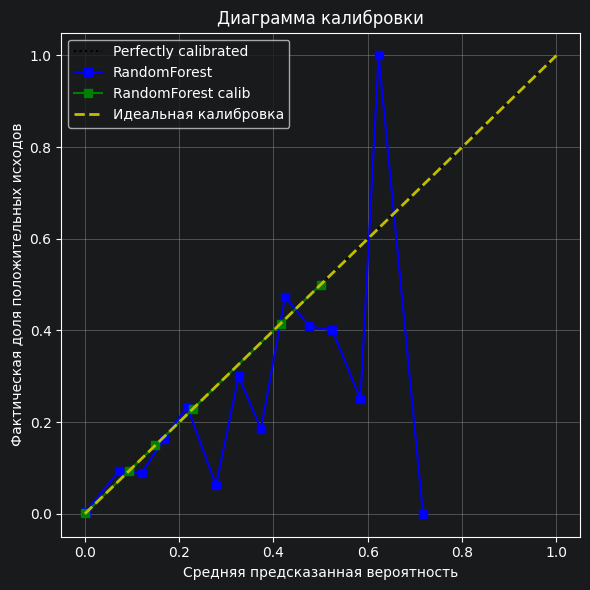

In [199]:
# Графики калибровок
fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay(prob_true_rf, prob_pred_rf, y_calib_t).plot(ax=ax, label='RandomForest', color='blue')
CalibrationDisplay(prob_true_rf_calib, prob_pred_rf_calib, y_calib_t).plot(ax=ax, label='RandomForest calib', color='green')
plt.plot([0, 1], [0, 1], 'y--', linewidth=2, label='Идеальная калибровка',)

plt.title("Диаграмма калибровки")
plt.xlabel("Средняя предсказанная вероятность")
plt.ylabel("Фактическая доля положительных исходов")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

Судя по оценке Бриера, изначально модель хорошо откалибрована, дополнительная калибровка немного улучшила(~2.3%) точность вероятностей модели. Но PR-AUC оцень низкий без калибровки, а с калибровкой еще немного снижается.

## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.



https://github.com/msesemov/DS_RandomForest_Sprint_15